# Local smooth=0.5 parameter-mismatch diagnostics

This notebook uses the existing local smooth=0.5, nugget=1 simulated July data. It runs or loads Vecchia conditional eigen diagnostics for smoothness, nugget, longitude-range, temporal-range, and advection mismatch experiments. Fit artifacts are saved per model, so rerunning the notebook does not repeat fitting unless `FORCE_REFIT=True`.

In [1]:
from pathlib import Path
import json
import shlex
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
DRIVER = REPO / 'Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis/vecchia_conditional_eigen_sort_sim_smooth0p5_parameter_mismatch_071126.py'
FULL_EIG_SCRIPT = REPO / 'Exercises/st_model/day/amarel_simulation/pure_space/eigen_diagnostic/eig_diag_real_july_st_full_eigen_matern_1of25_8h_070926.py'
RUN_STEM = 'sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126'

PYTHON_EXE = Path('/opt/anaconda3/envs/faiss_env/bin/python')
if not PYTHON_EXE.exists():
    PYTHON_EXE = Path(sys.executable)

assert DRIVER.exists(), DRIVER
assert FULL_EIG_SCRIPT.exists(), FULL_EIG_SCRIPT
print('DRIVER:', DRIVER)
print('FULL_EIG_SCRIPT:', FULL_EIG_SCRIPT)
print('PYTHON_EXE:', PYTHON_EXE)

DRIVER: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis/vecchia_conditional_eigen_sort_sim_smooth0p5_parameter_mismatch_071126.py
FULL_EIG_SCRIPT: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/pure_space/eigen_diagnostic/eig_diag_real_july_st_full_eigen_matern_1of25_8h_070926.py
PYTHON_EXE: /opt/anaconda3/envs/faiss_env/bin/python


## Configure

In [2]:
DATA_ROOT = Path('/Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5')
OUT_ROOT = REPO / 'outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126'
FULL_EIG_OUT_ROOT = REPO / 'outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126'

EXPERIMENTS = [
    'smooth_mismatch_dgp1',
    'nugget_mismatch_dgp1',
    'range_lon_mismatch_dgp1',
    'range_time_mismatch_dgp1',
    'advection_mismatch_dgp1',
]

YEAR = 2023
MONTH = 7
DAY = 1
DAYS = '0'
HOURS_PER_DAY = 8
TRUTH_NUGGET = 1.0

# Load/run controls.
RUN_VECCHIA = True
FORCE_REFIT = False
FORCE_REDIAGNOSE = False

# Full-eigen max-min sanity-check. This uses fitted full-data Vecchia summaries;
# it does not refit on the max-min subset.
RUN_FULL_EIG_MAXMIN = True
FULL_EIG_EXPERIMENTS = EXPERIMENTS
MAXMIN_POINTS_PER_HOUR = 400
FORCE_FULL_EIG = False

# Computation controls shared with the driver.
LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HISTORY = 10
TARGET_CHUNK_SIZE = 32
DIAG_CHUNK_SIZE = 64
DEVICE = 'cpu'

INPUT = DATA_ROOT / f'{YEAR}_july_st_circulant' / f'sim_july{YEAR}_st_circulant_gridded.pkl'
TRUTH_JSON = DATA_ROOT / f'{YEAR}_july_st_circulant' / f'sim_july{YEAR}_st_circulant_truth.json'

FULL_EIG_GROUP_BY_EXPERIMENT = {
    'smooth_mismatch_dgp1': 'smoothness',
    'nugget_mismatch_dgp1': 'nugget',
    'range_lon_mismatch_dgp1': 'range_lon_n1',
    'range_time_mismatch_dgp1': 'range_time_n1',
    'advection_mismatch_dgp1': 'advection_n1',
}

## Helpers

In [3]:
def run_stream(cmd):
    print(shlex.join([str(x) for x in cmd]))
    proc = subprocess.Popen([str(x) for x in cmd], cwd=str(REPO), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end='')
    ret = proc.wait()
    if ret != 0:
        raise RuntimeError(f'Command failed with exit code {ret}')


def summary_csv(experiment):
    return OUT_ROOT / experiment / f'{RUN_STEM}_{experiment}_summary.csv'


def vecchia_plot_png(experiment):
    return OUT_ROOT / experiment / 'daily_plots' / f'year_{YEAR}' / f'sim_{YEAR}_day01_vecchia_conditional_eigen_sort_comparison.png'


def full_eig_dir(experiment):
    return FULL_EIG_OUT_ROOT / experiment / f'year{YEAR}_day{DAY:02d}_maxmin{MAXMIN_POINTS_PER_HOUR}_per_hour'


def full_eig_summary_csv(experiment):
    return full_eig_dir(experiment) / 'st_full_eigen_summary.csv'


def full_eig_plot_png(experiment):
    return full_eig_dir(experiment) / 'st_full_eigen_model_comparison.png'


def show_existing(paths):
    for path in paths:
        print(('OK  ' if Path(path).exists() else 'MISS') + ' ' + str(path))

## Validate data

In [4]:
if not INPUT.exists():
    raise FileNotFoundError(f'INPUT does not exist: {INPUT}')
if not TRUTH_JSON.exists():
    raise FileNotFoundError(f'TRUTH_JSON does not exist: {TRUTH_JSON}')

truth = json.loads(TRUTH_JSON.read_text())
print(json.dumps(truth, indent=2, sort_keys=True))
if abs(float(truth.get('smooth')) - 0.5) > 1e-12 or abs(float(truth.get('nugget')) - TRUTH_NUGGET) > 1e-12:
    raise RuntimeError(f'Expected smooth=0.5 nugget={TRUTH_NUGGET}, got truth={truth}')
if int(truth.get('n_hours', 0)) < HOURS_PER_DAY:
    raise RuntimeError(f'Need at least {HOURS_PER_DAY} hours, got truth={truth}')

show_existing([INPUT, TRUTH_JSON])

{
  "advec_lat": 0.08,
  "advec_lon": -0.2,
  "block_generation": "independent daily 8-hour 3D circulant embeddings",
  "delta_lat_base": 0.044,
  "delta_lat_hr": 0.00043999999999999996,
  "delta_lon_base": 0.063,
  "delta_lon_hr": 0.0063,
  "griddification_rule": "nearest regular grid cell, 1-to-1, then axis-wise half-cell threshold",
  "griddification_threshold_lat": 0.022,
  "griddification_threshold_lon": 0.0315,
  "hours_per_day": 8,
  "hr_pad": 0.1,
  "input_template": "/home/jl2815/tco/data/pickle_2023/tco_grid_23_07.pkl",
  "lat_factor_hr": 100,
  "lat_range": [
    -3.0,
    2.0
  ],
  "lon_factor_hr": 10,
  "lon_range": [
    121.0,
    131.0
  ],
  "mean_intercept": 260.0,
  "mean_lat_center": -0.5,
  "mean_lat_slope": 1.0,
  "n_hours": 248,
  "nugget": 1.0,
  "range_lat": 0.2,
  "range_lon": 0.3,
  "range_time": 2.0,
  "sigma": 3.1622776601683795,
  "sigmasq": 10.0,
  "smooth": 0.5,
  "year": 2023
}
OK   /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_rea

## Run or load Vecchia conditional eigen diagnostics

In [5]:
base_cmd = [
    PYTHON_EXE,
    DRIVER,
    '--data-root', DATA_ROOT,
    '--out-root', OUT_ROOT,
    '--years', str(YEAR),
    '--month', str(MONTH),
    '--days', DAYS,
    '--hours-per-day', str(HOURS_PER_DAY),
    '--truth-nugget', str(TRUTH_NUGGET),
    '--sim-kind', 'gridded',
    '--lat-range=-3,2',
    '--lon-range=121,131',
    '--real-reference-advec-lon-abs', '0.126',
    '--daily-stride', '2',
    '--target-chunk-size', str(TARGET_CHUNK_SIZE),
    '--diag-chunk-size', str(DIAG_CHUNK_SIZE),
    '--min-target-points', '1',
    '--spline-n-points', '4000',
    '--spline-r-max', '30.0',
    '--lbfgs-lr', '1.0',
    '--lbfgs-steps', str(LBFGS_STEPS),
    '--lbfgs-eval', str(LBFGS_EVAL),
    '--lbfgs-history', str(LBFGS_HISTORY),
    '--grad-tol', '1e-5',
    '--device', DEVICE,
    '--cuda-fallback', 'cpu',
    '--brown-bridge-q', '1.3581015157406195',
    '--resample-grid', '200',
    '--save-daily-curves',
    '--suppress-fit-prints',
]
if FORCE_REFIT:
    base_cmd.append('--force-refit')
if FORCE_REDIAGNOSE:
    base_cmd.append('--force-rediagnose')

if RUN_VECCHIA:
    for experiment in EXPERIMENTS:
        summary_path = summary_csv(experiment)
        plot_path = vecchia_plot_png(experiment)
        if summary_path.exists() and plot_path.exists() and not FORCE_REFIT and not FORCE_REDIAGNOSE:
            print(f'Reusing Vecchia outputs for {experiment}.')
            show_existing([summary_path, plot_path])
            continue
        cmd = [*base_cmd, '--experiment', experiment]
        run_stream(cmd)
else:
    print('RUN_VECCHIA=False; loading existing summaries only.')

/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/eigen_analysis/vecchia_conditional_eigen_sort_sim_smooth0p5_parameter_mismatch_071126.py --data-root /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5 --out-root /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126 --years 2023 --month 7 --days 0 --hours-per-day 8 --truth-nugget 1.0 --sim-kind gridded --lat-range=-3,2 --lon-range=121,131 --real-reference-advec-lon-abs 0.126 --daily-stride 2 --target-chunk-size 32 --diag-chunk-size 64 --min-target-points 1 --spline-n-points 4000 --spline-r-max 30.0 --lbfgs-lr 1.0 --lbfgs-steps 5 --lbfgs-eval 20 --lbfgs-history 10 --grad-tol 1e-5 --device cpu --cuda-fallback cpu --brown-bridge-q 1.3581015157406195 --resample-grid 200 --save-daily-curves --suppress-fit-prints --experiment smooth_mismatch_dgp1
R

## Show Vecchia summaries and plots

,experiment,model_variant,model_label,status,vecchia_loss_per_obs,conditional_loss_per_score,mean_y2,max_abs_bridge_scaled,smooth,fixed_nugget,...,advec_mode,est_sigmasq,est_range_lat,est_range_lon,est_range_time,est_advec_lat,est_advec_lon,est_nugget,fit_s,diag_s
0,smooth_mismatch_dgp1,matern_s03_n1,Matern s=0.3 nugget1 rough,ok,1.134753,1.134753,0.971348,13.447872,0.3,1.0,...,free,15.863008,0.902543,1.377783,8.193822,0.083472,-0.196389,1.0,883.146198,4.020684
1,smooth_mismatch_dgp1,matern_s05_n1,Matern s=0.5 nugget1 true,ok,1.126352,1.126352,1.000508,0.860487,0.5,1.0,...,free,9.589804,0.190875,0.287604,1.910050,0.081581,-0.196064,1.0,226.153236,2.201047
2,smooth_mismatch_dgp1,matern_s10_n1,Matern s=1.0 nugget1 smooth,ok,1.137984,1.137984,1.046906,12.486960,1.0,1.0,...,free,6.954943,0.084564,0.125513,0.991966,0.078717,-0.196668,1.0,550.782375,3.970910
3,nugget_mismatch_dgp1,matern_s05_n0,Matern s=0.5 nugget0 under,ok,1.133558,1.133547,1.000073,13.623031,0.5,0.0,...,free,8.583737,0.100607,0.149309,1.140418,0.079508,-0.195609,0.0,5270.906498,3.679089
4,nugget_mismatch_dgp1,matern_s05_n1,Matern s=0.5 nugget1 true,ok,1.126352,1.126352,1.000508,0.860487,0.5,1.0,...,free,9.589804,0.190875,0.287604,1.910050,0.081581,-0.196064,1.0,623.867575,2.253666
5,nugget_mismatch_dgp1,matern_s05_n2,Matern s=0.5 nugget2 over,ok,1.136300,1.136300,0.919670,21.351119,0.5,2.0,...,free,14.607444,0.465648,0.712023,4.300574,0.083617,-0.197273,2.0,271.212423,2.282712
6,range_lon_mismatch_dgp1,matern_s05_n1_rangelon_short,Matern s=0.5 nugget1 range_lon=0.15,ok,1.160642,1.130486,0.985529,5.473807,0.5,1.0,...,free,5.772001,0.107407,0.150000,1.045402,0.080170,-0.193975,1.0,177.657751,2.413670
7,range_lon_mismatch_dgp1,matern_s05_n1_rangelon_true,Matern s=0.5 nugget1 range_lon true,ok,1.126374,1.126358,1.001006,0.798895,0.5,1.0,...,free,9.965525,0.198898,0.300000,1.994768,0.081632,-0.196194,1.0,159.666394,2.269782
8,range_lon_mismatch_dgp1,matern_s05_n1_rangelon_long,Matern s=0.5 nugget1 range_lon=0.60,ok,1.127101,1.127101,1.005249,1.510550,0.5,1.0,...,free,19.372577,0.396624,0.600000,4.085081,0.082246,-0.197637,1.0,212.693730,2.232476
9,range_time_mismatch_dgp1,matern_s05_n1_rangetime_short,Matern s=0.5 nugget1 range_time=1,ok,1.133138,1.128791,0.993916,2.088695,0.5,1.0,...,free,6.542253,0.124570,0.187882,1.000000,0.079309,-0.193599,1.0,134.032361,2.237860



smooth_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/smooth_mismatch_dgp1/sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126_smooth_mismatch_dgp1_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/smooth_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


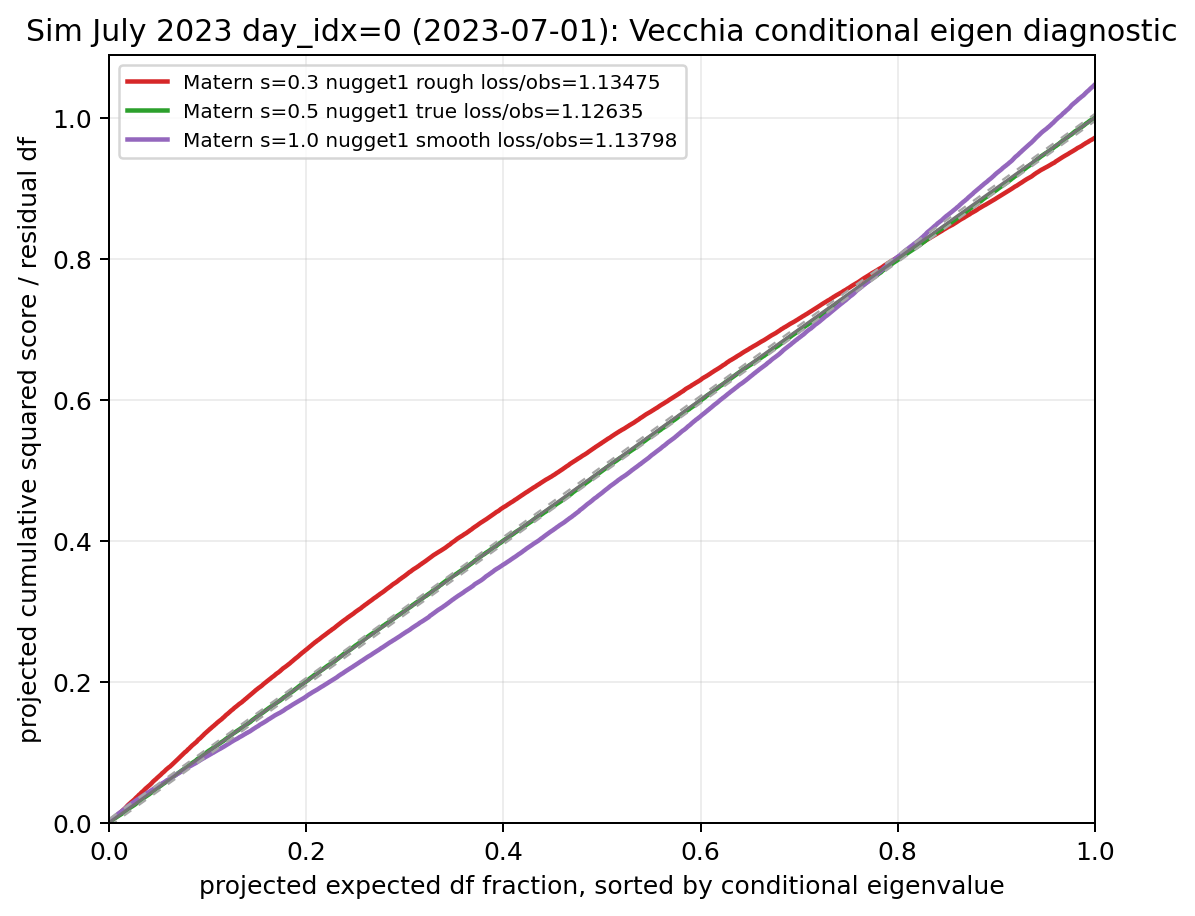


nugget_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/nugget_mismatch_dgp1/sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126_nugget_mismatch_dgp1_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/nugget_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


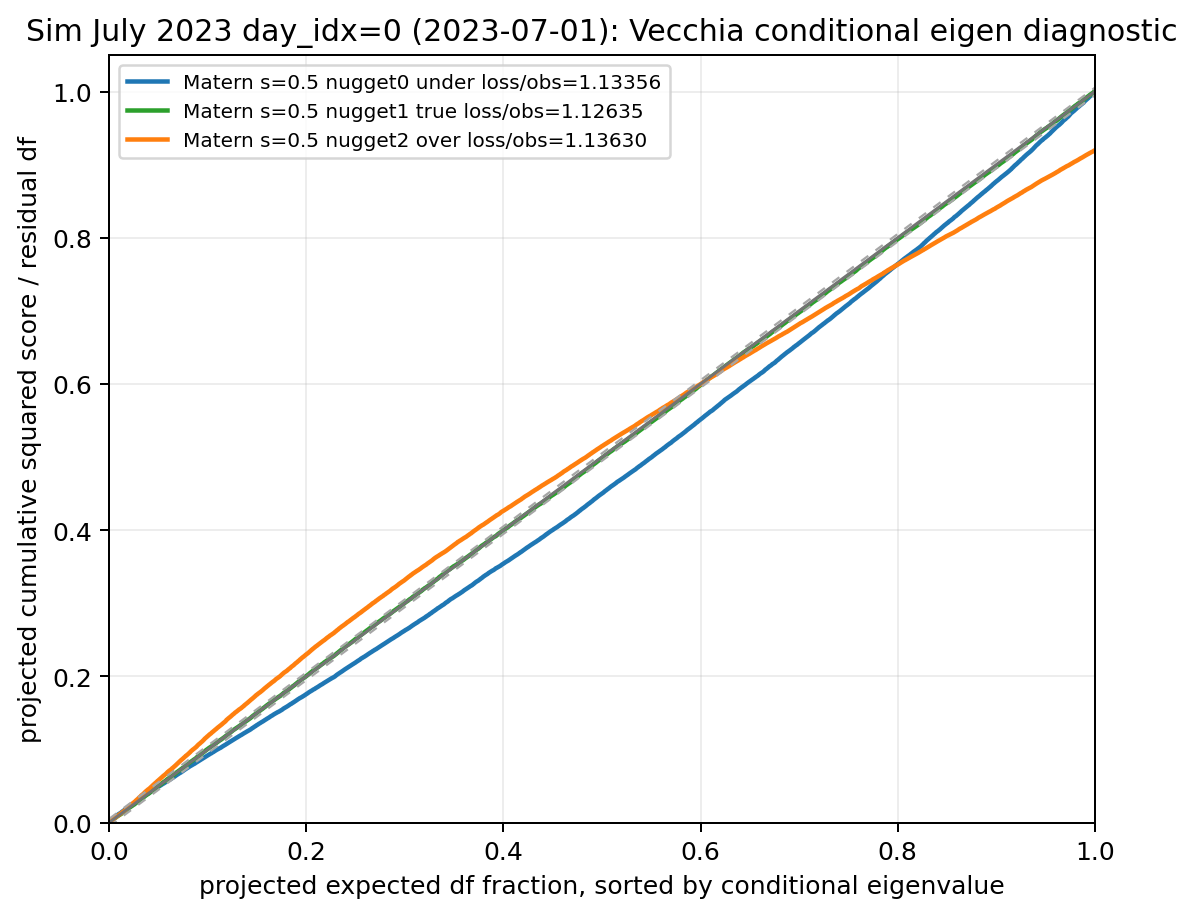


range_lon_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/range_lon_mismatch_dgp1/sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126_range_lon_mismatch_dgp1_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/range_lon_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


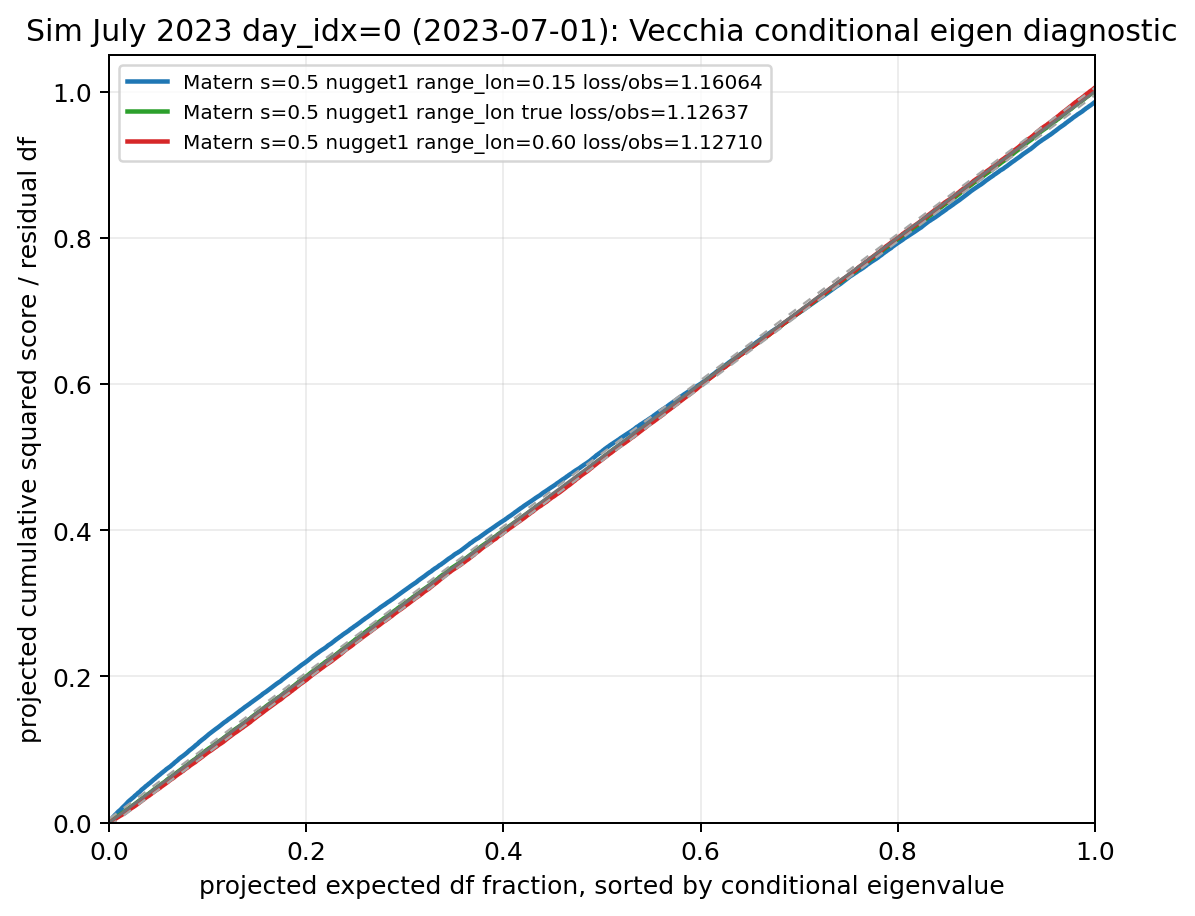


range_time_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/range_time_mismatch_dgp1/sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126_range_time_mismatch_dgp1_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/range_time_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


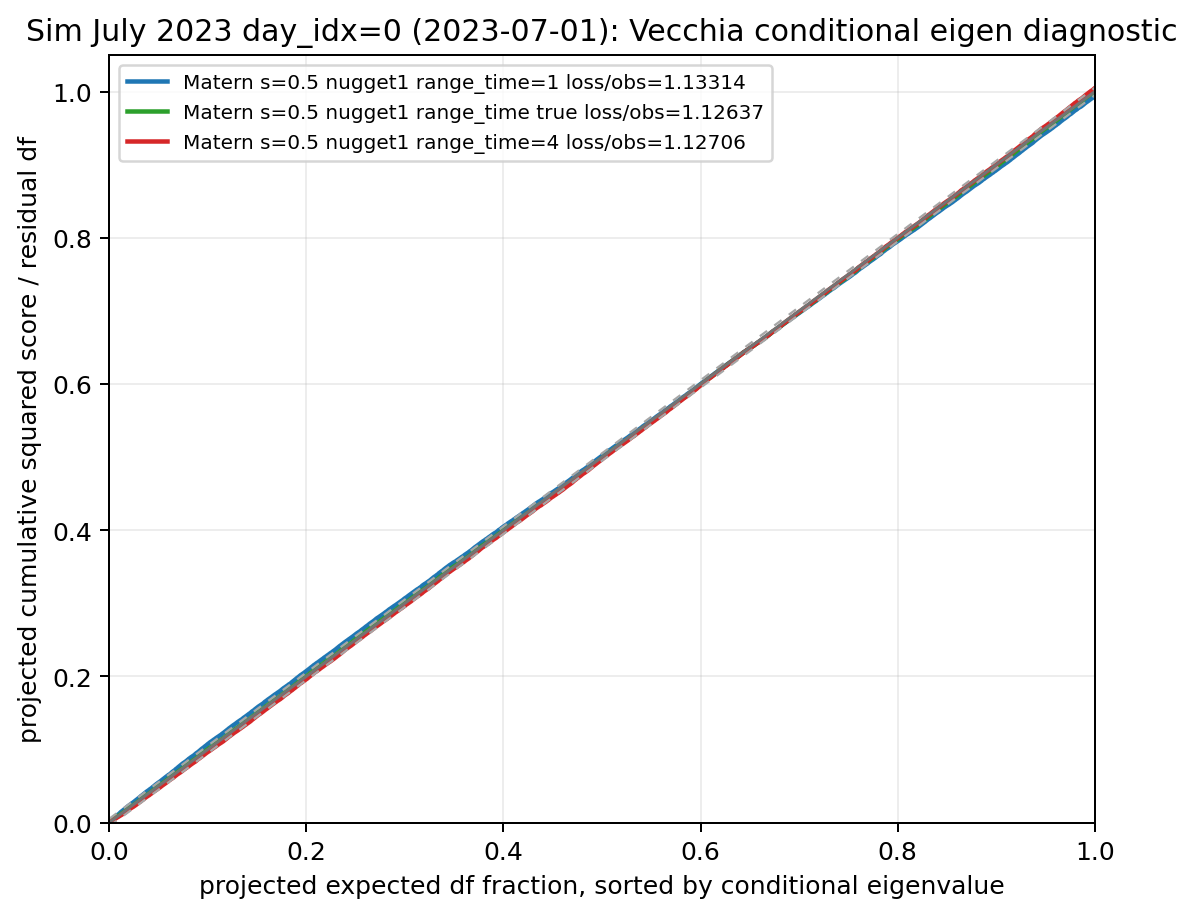


advection_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/advection_mismatch_dgp1/sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126_advection_mismatch_dgp1_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/advection_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


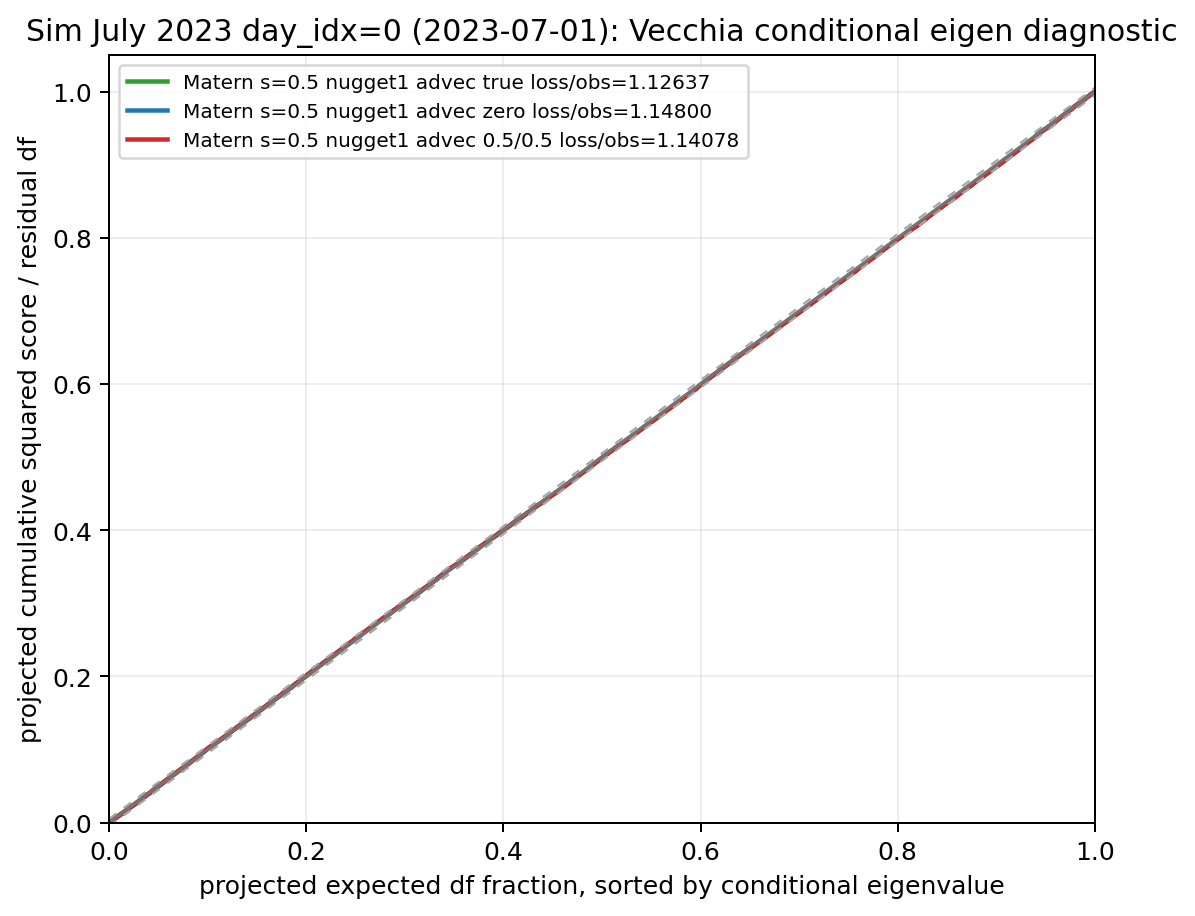

In [6]:
summary_frames = []
for experiment in EXPERIMENTS:
    path = summary_csv(experiment)
    if not path.exists():
        print('Missing summary:', path)
        continue
    df = pd.read_csv(path)
    df.insert(0, 'experiment', experiment)
    summary_frames.append(df)

if not summary_frames:
    raise FileNotFoundError('No Vecchia summaries found.')

vecchia_summary = pd.concat(summary_frames, ignore_index=True)
cols = [
    'experiment', 'model_variant', 'model_label', 'status', 'vecchia_loss_per_obs',
    'conditional_loss_per_score', 'mean_y2', 'max_abs_bridge_scaled',
    'smooth', 'fixed_nugget', 'range_lon_mode', 'range_time_mode', 'advec_mode',
    'est_sigmasq', 'est_range_lat', 'est_range_lon', 'est_range_time',
    'est_advec_lat', 'est_advec_lon', 'est_nugget', 'fit_s', 'diag_s'
]
cols = [c for c in cols if c in vecchia_summary.columns]
display(vecchia_summary[cols])

for experiment in EXPERIMENTS:
    plot_path = vecchia_plot_png(experiment)
    print('\n' + experiment)
    print('summary:', summary_csv(experiment))
    print('plot:', plot_path)
    if plot_path.exists():
        display(Image(filename=str(plot_path)))

## Run or load max-min full eigen diagnostics

This section takes the first 400 max-min ordered spatial locations for each of the 8 hours. The parameter values come from the full-data Vecchia fit summaries above; no subset fitting is done here.

In [7]:
if RUN_FULL_EIG_MAXMIN:
    for experiment in FULL_EIG_EXPERIMENTS:
        summary_path = summary_csv(experiment)
        if not summary_path.exists():
            raise FileNotFoundError(f'Vecchia summary needed before full eigen: {summary_path}')
        group = FULL_EIG_GROUP_BY_EXPERIMENT[experiment]
        out_root = FULL_EIG_OUT_ROOT / experiment
        full_summary = full_eig_summary_csv(experiment)
        full_plot = full_eig_plot_png(experiment)
        if full_summary.exists() and full_plot.exists() and not FORCE_FULL_EIG:
            print(f'Reusing full-eigen maxmin outputs for {experiment}.')
            show_existing([full_summary, full_plot])
            continue
        cmd = [
            PYTHON_EXE,
            FULL_EIG_SCRIPT,
            '--input', INPUT,
            '--vecchia-summary', summary_path,
            '--output-root', out_root,
            '--year', str(YEAR),
            '--month', str(MONTH),
            '--day', str(DAY),
            '--hours-per-day', str(HOURS_PER_DAY),
            '--subset-mode', 'maxmin',
            '--maxmin-points-per-hour', str(MAXMIN_POINTS_PER_HOUR),
            '--model-variants', group,
            '--save-selected-points',
        ]
        run_stream(cmd)
else:
    print('RUN_FULL_EIG_MAXMIN=False; loading existing full-eigen outputs only.')

/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/pure_space/eigen_diagnostic/eig_diag_real_july_st_full_eigen_matern_1of25_8h_070926.py --input /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2023_july_st_circulant/sim_july2023_st_circulant_gridded.pkl --vecchia-summary /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/smooth_mismatch_dgp1/sim_july_st_s05_vecchia_conditional_eigen_sort_parameter_mismatch_071126_smooth_mismatch_dgp1_summary.csv --output-root /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/smooth_mismatch_dgp1 --year 2023 --month 7 --day 1 --hours-per-day 8 --subset-mode maxmin --maxmin-points-per-hour 400 --model-variants smoothness --save-selected-points
Loaded ST subset: n=3113, hours=8, spatial/hour=[400,

## Show max-min full eigen results

,experiment,variant,label,source_model_variant,source_vecchia_loss_per_obs,loss_per_obs,score2_per_df,max_abs_bridge_scaled,n_obs,residual_df,subset_mode,maxmin_points_per_hour,est_sigmasq,est_range_lat,est_range_lon,est_range_time,est_advec_lat,est_advec_lon,est_nugget
0,smooth_mismatch_dgp1,s05_n1,Matern s=0.5 nugget1 reference,matern_s05_n1,1.126352,2.471087,0.992952,0.358525,3113,3104.0,maxmin,400,9.589804,0.190875,0.287604,1.910050,0.081581,-0.196064,1.0
1,smooth_mismatch_dgp1,s03_n1,Matern s=0.3 nugget1 rough,matern_s03_n1,1.134753,2.491656,1.185452,7.418337,3113,3104.0,maxmin,400,15.863008,0.902543,1.377783,8.193822,0.083472,-0.196389,1.0
2,smooth_mismatch_dgp1,s10_n1,Matern s=1.0 nugget1 smooth,matern_s10_n1,1.137984,2.521069,1.165035,9.562001,3113,3104.0,maxmin,400,6.954943,0.084564,0.125513,0.991966,0.078717,-0.196668,1.0
3,nugget_mismatch_dgp1,s05_n0,Matern s=0.5 nugget0 under,matern_s05_n0,1.133558,2.491397,1.064200,5.424435,3113,3104.0,maxmin,400,8.583737,0.100607,0.149309,1.140418,0.079508,-0.195609,0.0
4,nugget_mismatch_dgp1,s05_n1,Matern s=0.5 nugget1 reference,matern_s05_n1,1.126352,2.471087,0.992952,0.358525,3113,3104.0,maxmin,400,9.589804,0.190875,0.287604,1.910050,0.081581,-0.196064,1.0
5,nugget_mismatch_dgp1,s05_n2,Matern s=0.5 nugget2 over,matern_s05_n2,1.136300,2.484453,1.025418,1.782301,3113,3104.0,maxmin,400,14.607444,0.465648,0.712023,4.300574,0.083617,-0.197273,2.0
6,range_lon_mismatch_dgp1,s05_n1_rangelon_short,Matern s=0.5 nugget1 range_lon=0.15,matern_s05_n1_rangelon_short,1.160642,2.522033,1.344506,13.970270,3113,3104.0,maxmin,400,5.772001,0.107407,0.150000,1.045402,0.080170,-0.193975,1.0
7,range_lon_mismatch_dgp1,s05_n1_rangelon_true,Matern s=0.5 nugget1 range_lon true,matern_s05_n1_rangelon_true,1.126374,2.471365,0.979779,0.867445,3113,3104.0,maxmin,400,9.965525,0.198898,0.300000,1.994768,0.081632,-0.196194,1.0
8,range_lon_mismatch_dgp1,s05_n1_rangelon_long,Matern s=0.5 nugget1 range_lon=0.60,matern_s05_n1_rangelon_long,1.127101,2.491402,0.866320,5.393405,3113,3104.0,maxmin,400,19.372577,0.396624,0.600000,4.085081,0.082246,-0.197637,1.0
9,range_time_mismatch_dgp1,s05_n1_rangetime_short,Matern s=0.5 nugget1 range_time=1,matern_s05_n1_rangetime_short,1.133138,2.499683,1.212771,9.356524,3113,3104.0,maxmin,400,6.542253,0.124570,0.187882,1.000000,0.079309,-0.193599,1.0



smooth_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/smooth_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/smooth_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


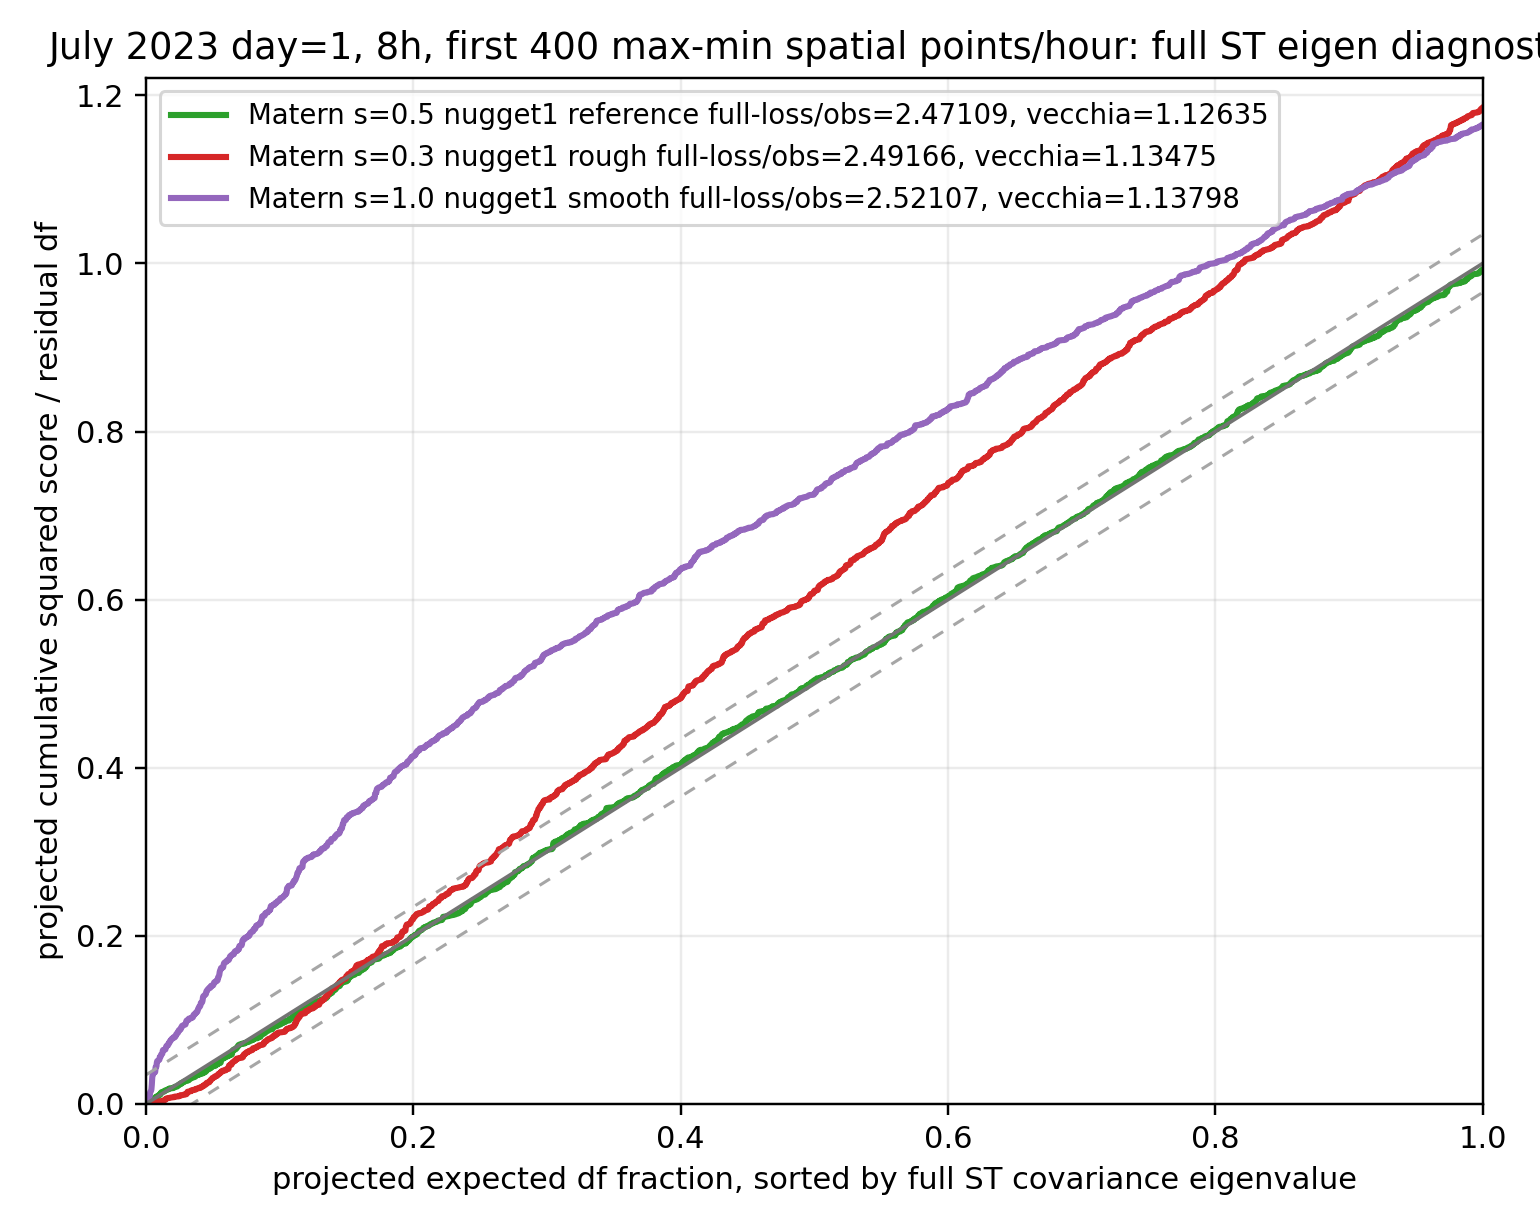


nugget_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/nugget_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/nugget_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


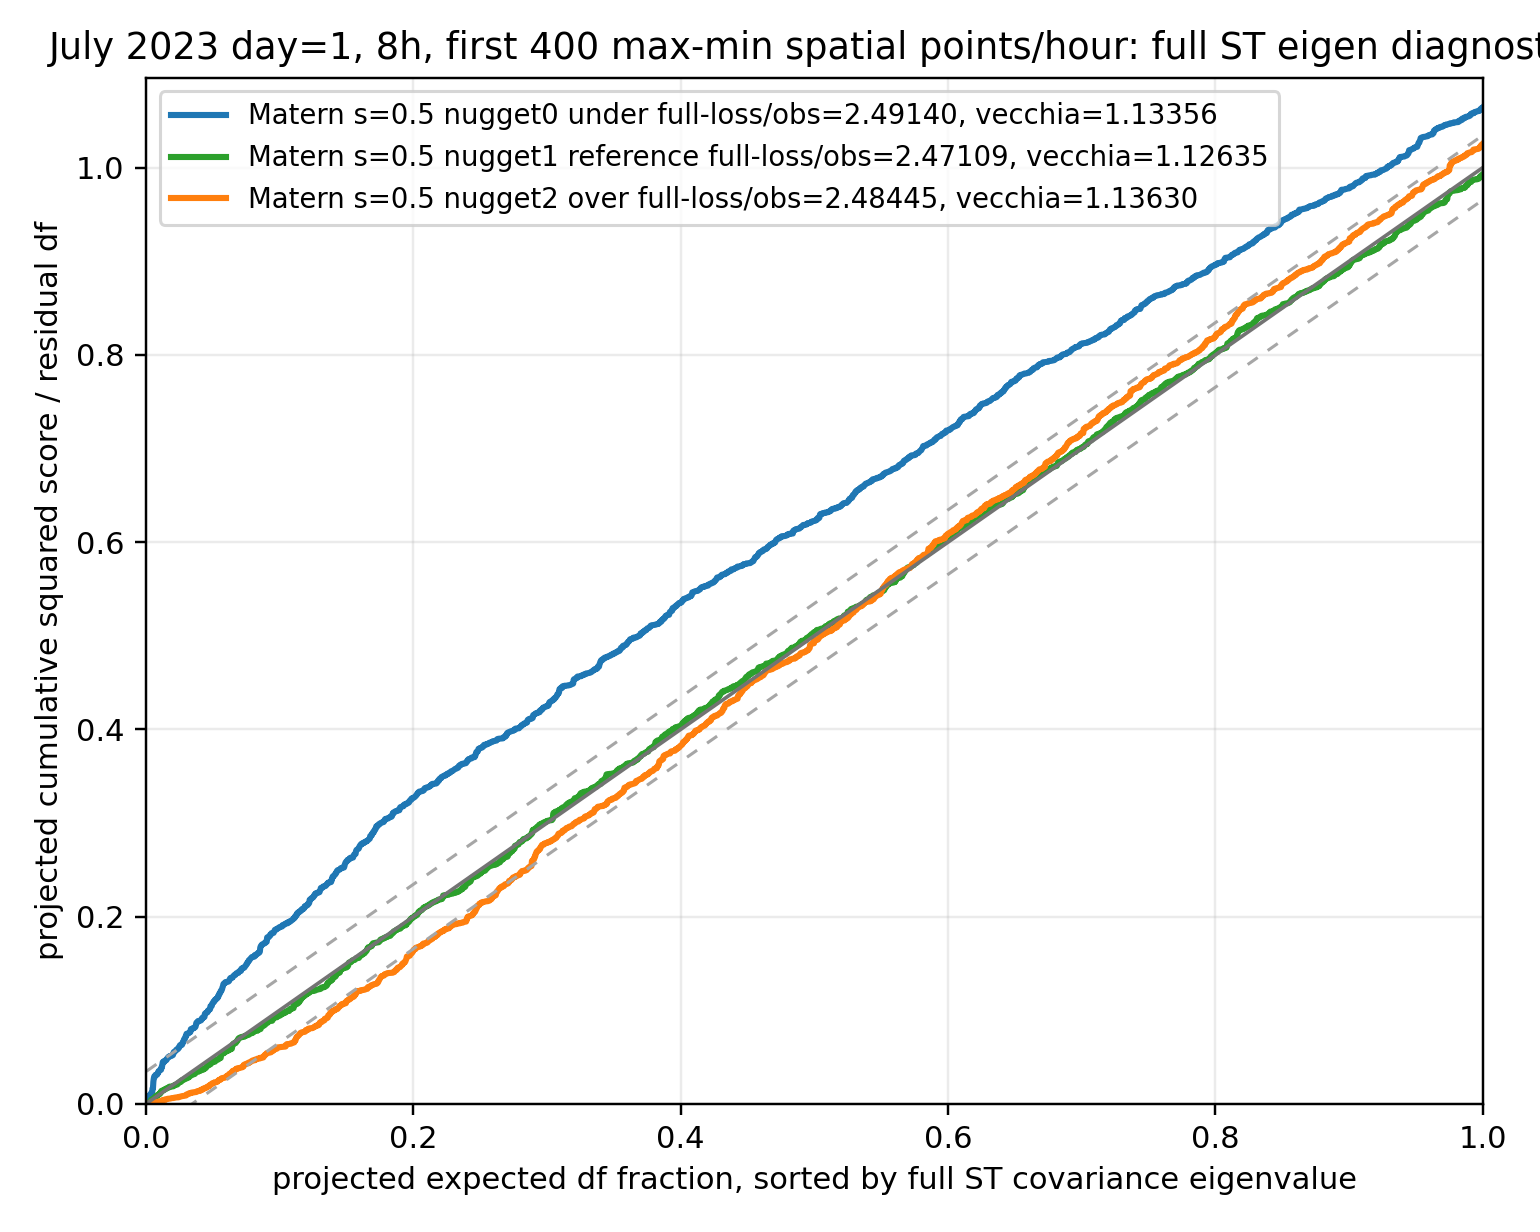


range_lon_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/range_lon_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/range_lon_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


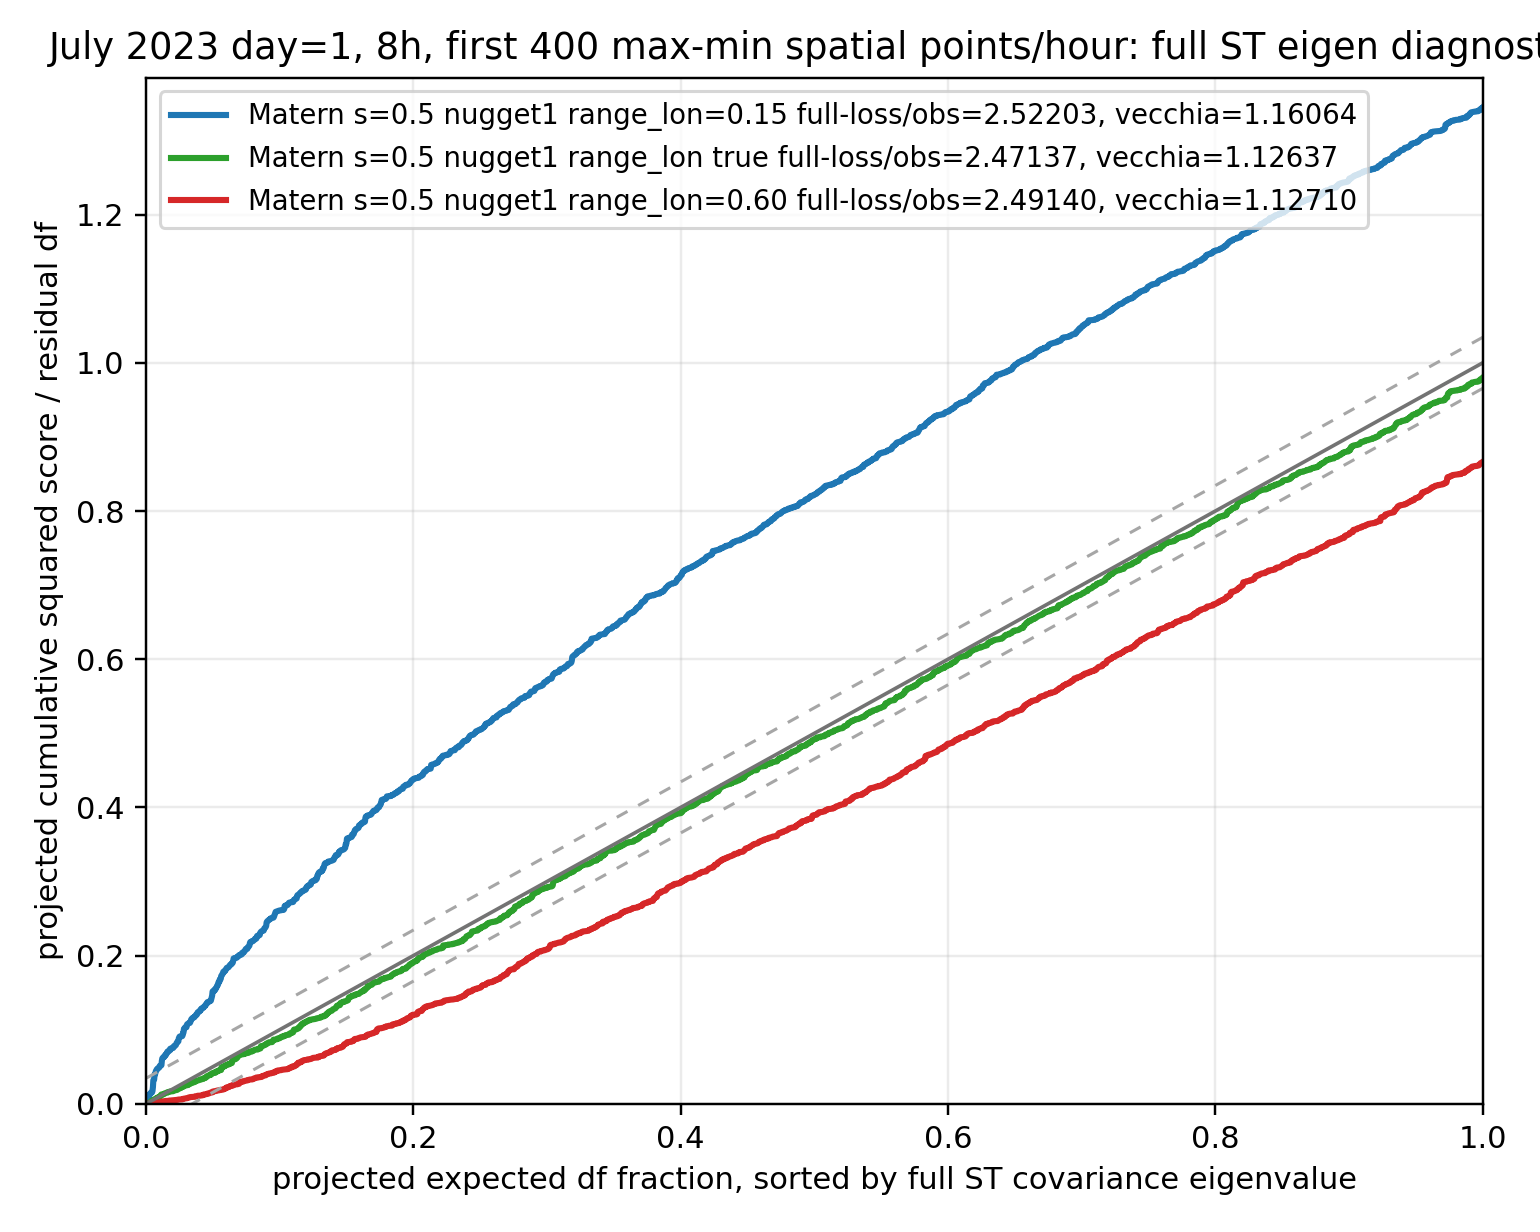


range_time_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/range_time_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/range_time_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


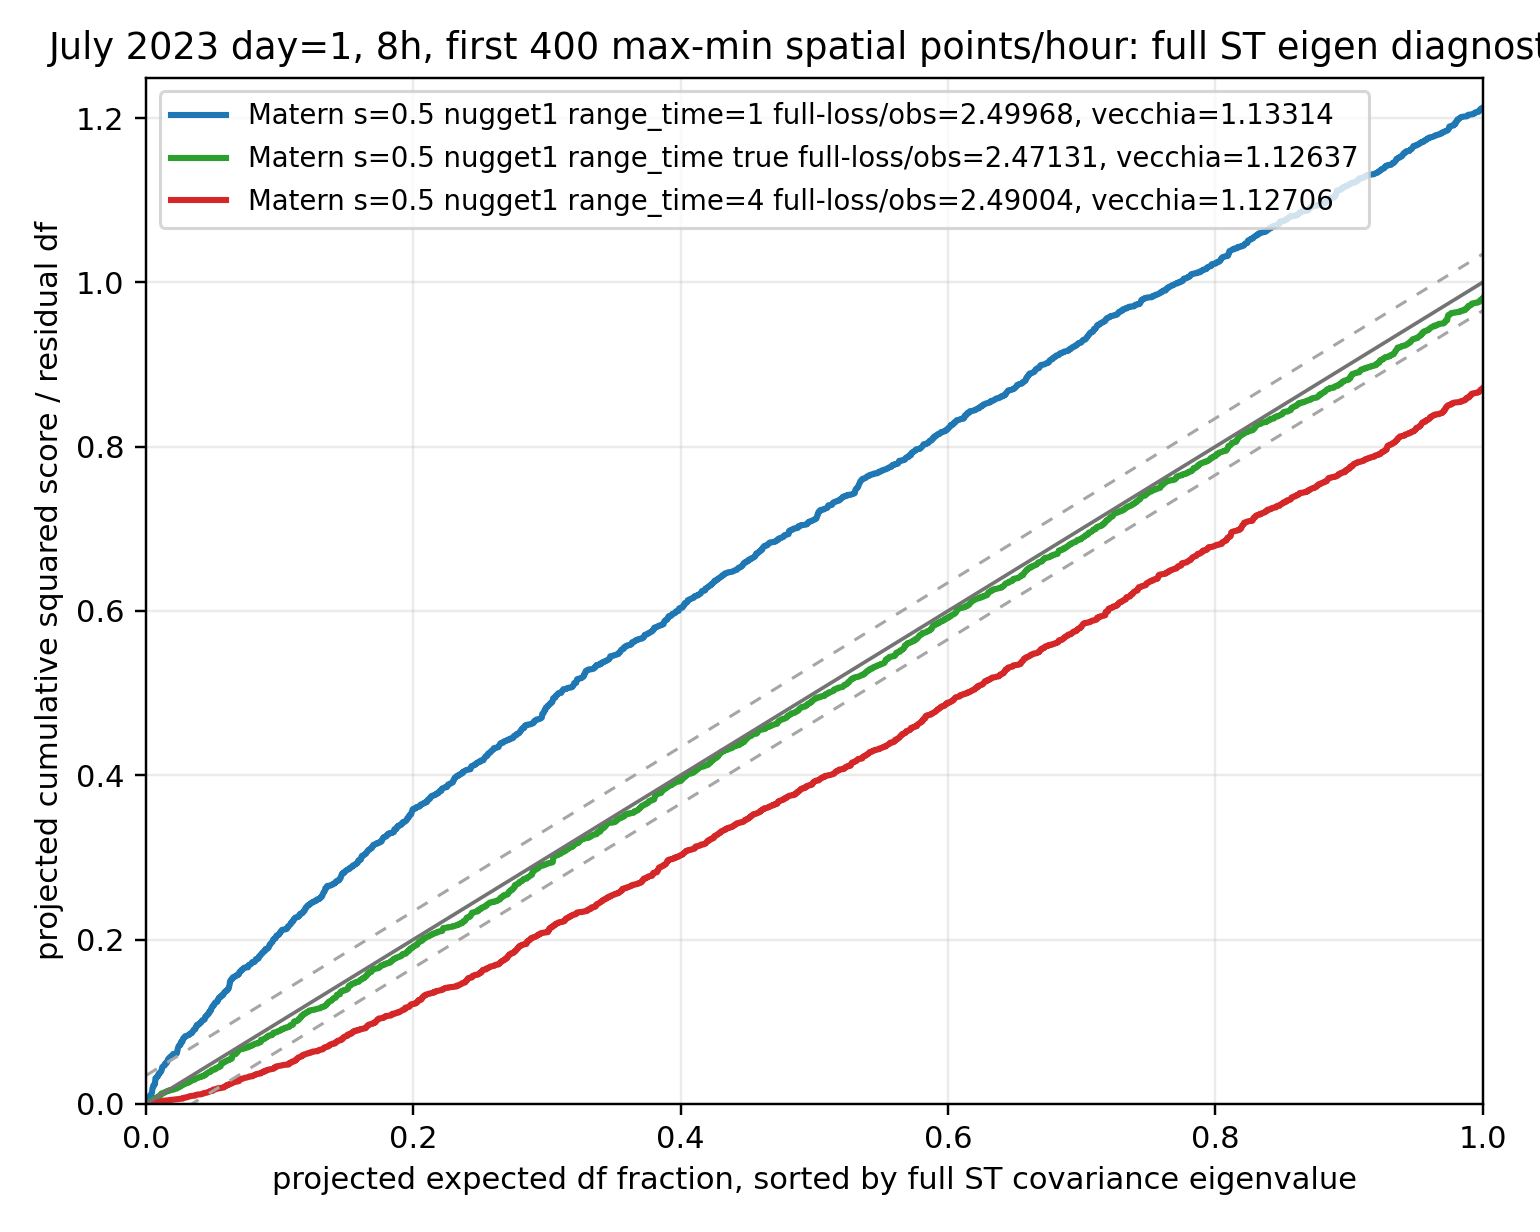


advection_mismatch_dgp1
summary: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/advection_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_summary.csv
plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/advection_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


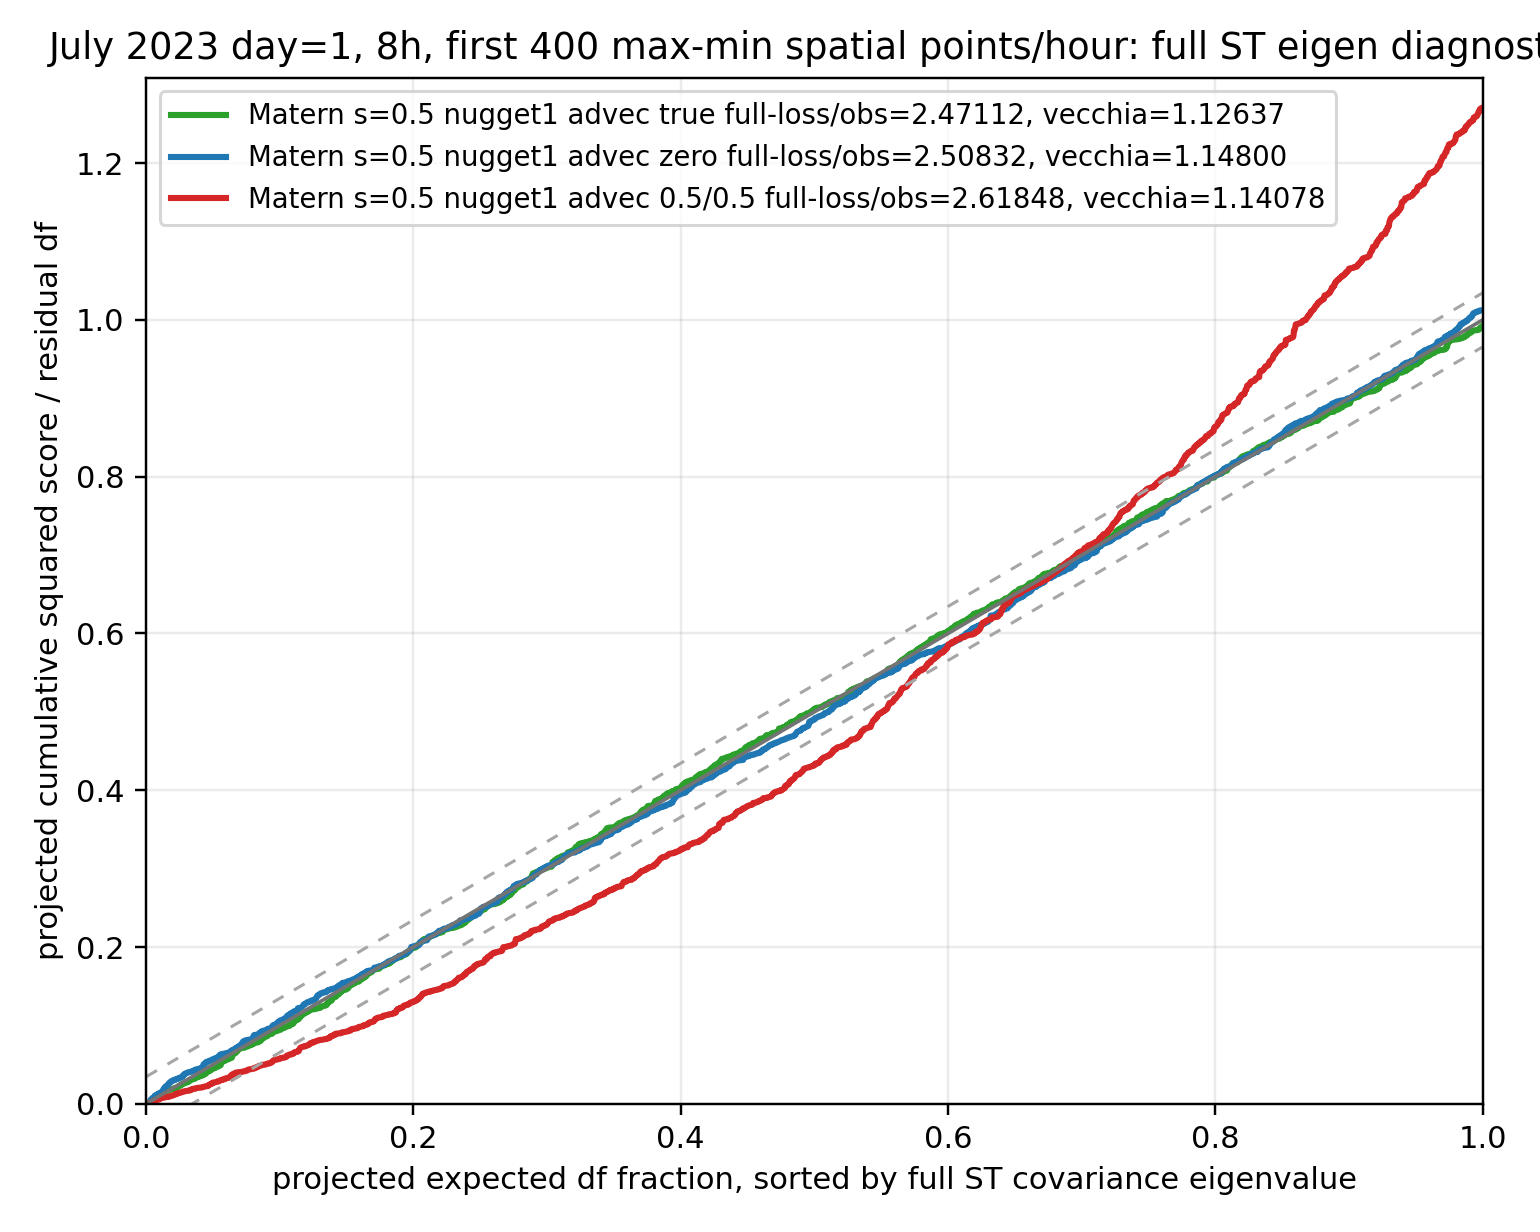

In [8]:
full_frames = []
for experiment in FULL_EIG_EXPERIMENTS:
    path = full_eig_summary_csv(experiment)
    if not path.exists():
        print('Missing full-eigen summary:', path)
        continue
    df = pd.read_csv(path)
    df.insert(0, 'experiment', experiment)
    full_frames.append(df)

if full_frames:
    full_eig_summary = pd.concat(full_frames, ignore_index=True)
    full_cols = [
        'experiment', 'variant', 'label', 'source_model_variant',
        'source_vecchia_loss_per_obs', 'loss_per_obs', 'score2_per_df',
        'max_abs_bridge_scaled', 'n_obs', 'residual_df', 'subset_mode',
        'maxmin_points_per_hour', 'est_sigmasq', 'est_range_lat',
        'est_range_lon', 'est_range_time', 'est_advec_lat', 'est_advec_lon', 'est_nugget'
    ]
    full_cols = [c for c in full_cols if c in full_eig_summary.columns]
    display(full_eig_summary[full_cols])

for experiment in FULL_EIG_EXPERIMENTS:
    plot_path = full_eig_plot_png(experiment)
    print('\n' + experiment)
    print('summary:', full_eig_summary_csv(experiment))
    print('plot:', plot_path)
    if plot_path.exists():
        display(Image(filename=str(plot_path)))

## Case-wise paired plots

Each mismatch case should have two diagnostics: the full-domain Vecchia conditional eigen plot, and the max-min 400-per-hour by 8-hour full eigen plot using the same fitted parameters.


smooth_mismatch_dgp1
Vecchia eigen plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/smooth_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


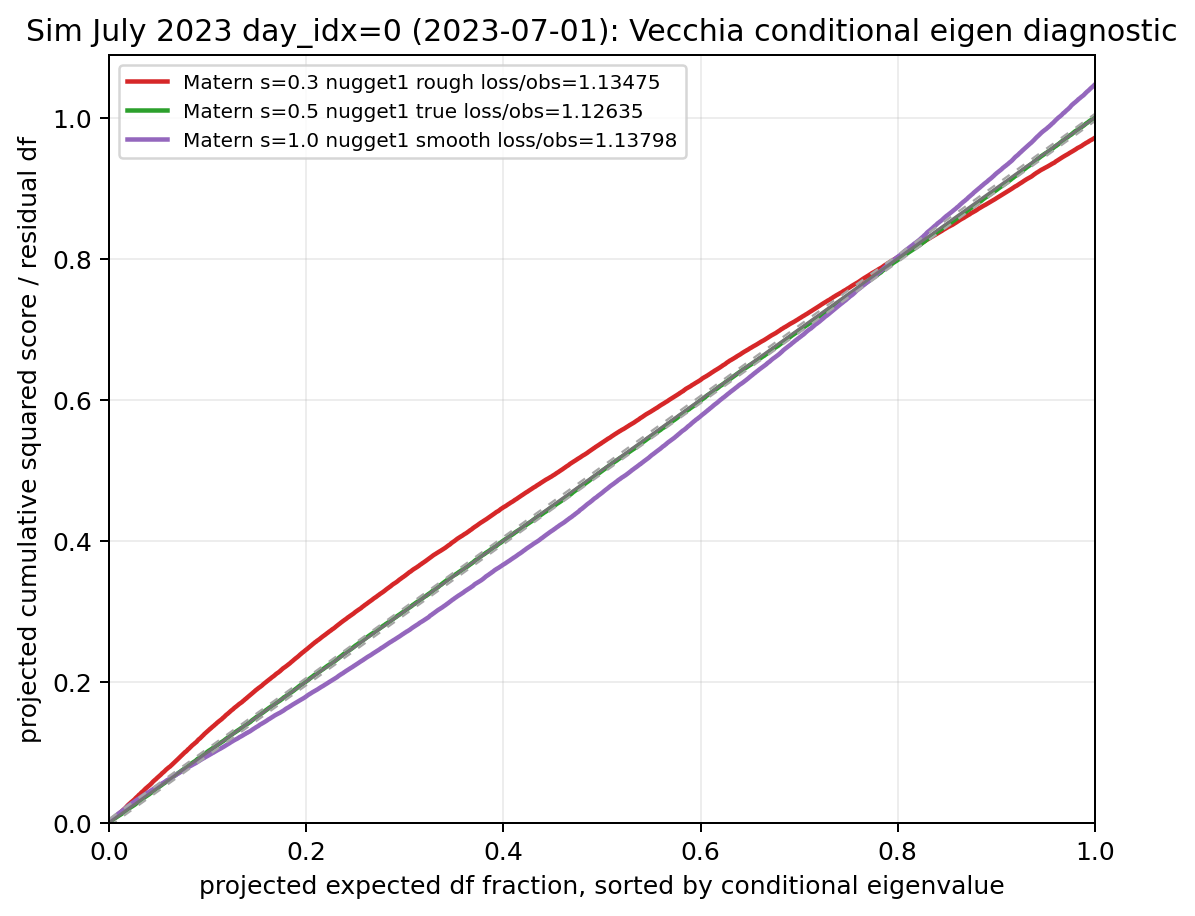

Full eigen maxmin plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/smooth_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


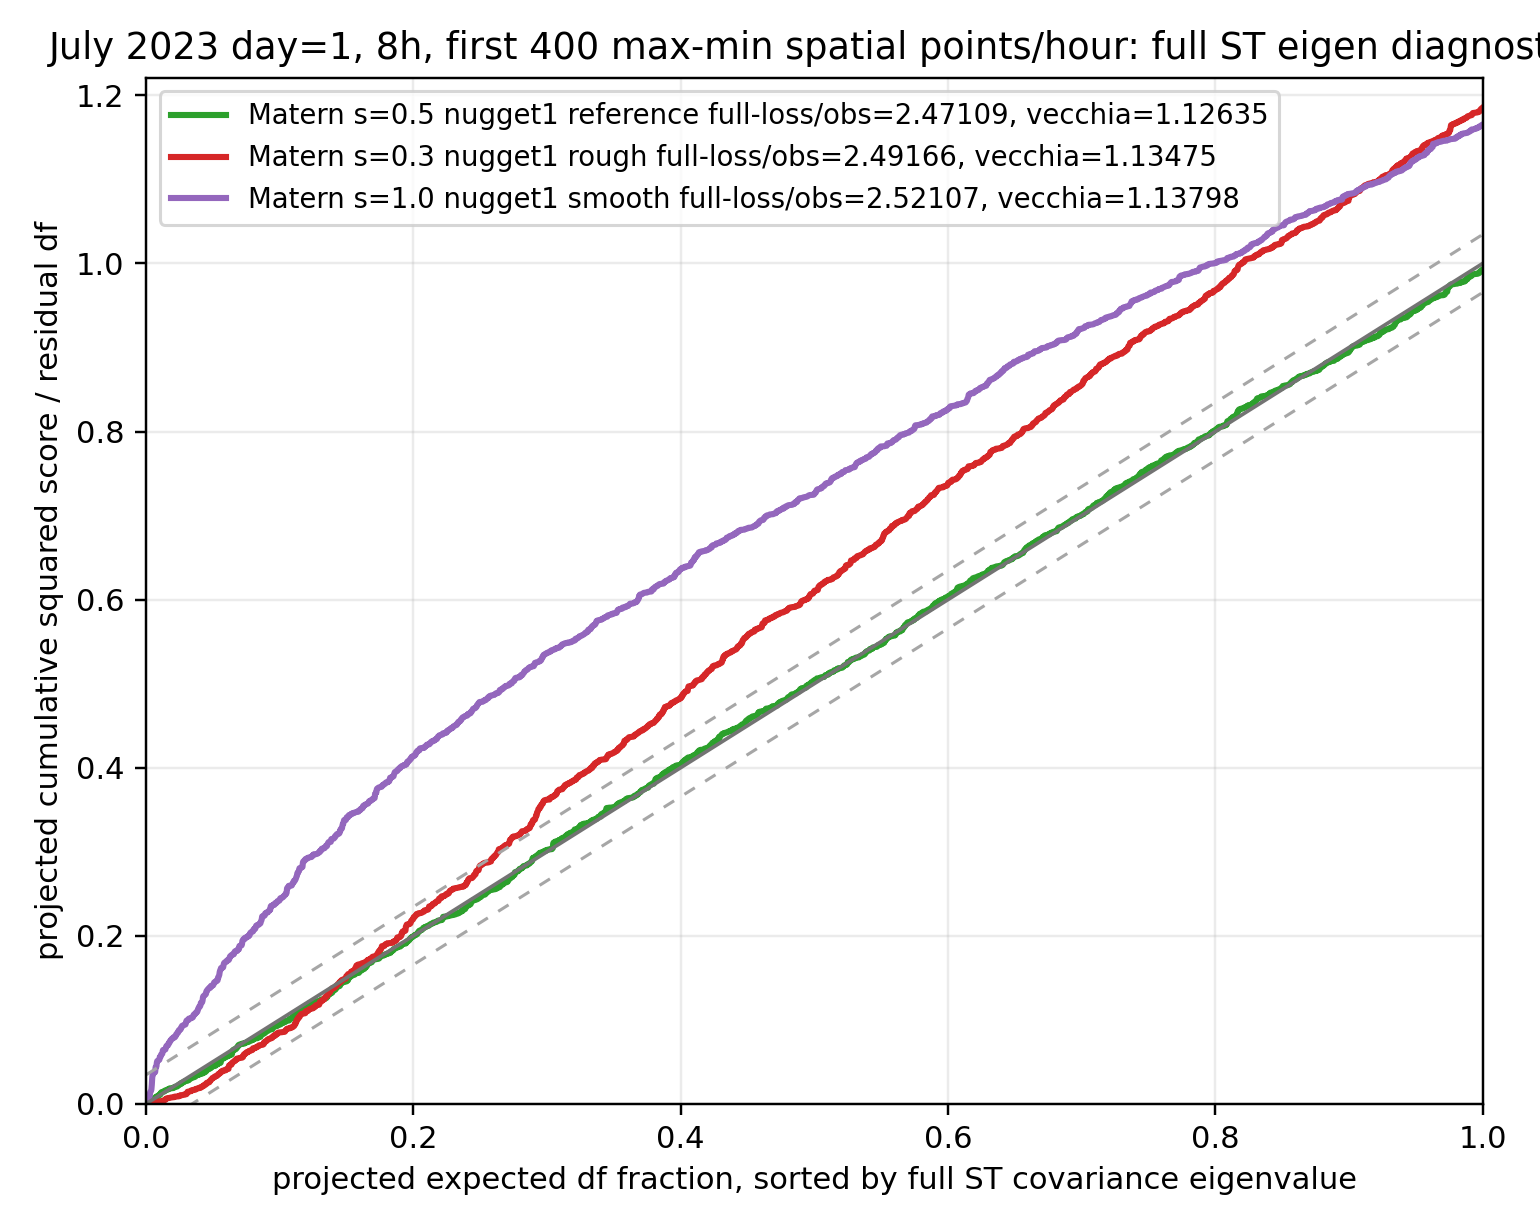


nugget_mismatch_dgp1
Vecchia eigen plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/nugget_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


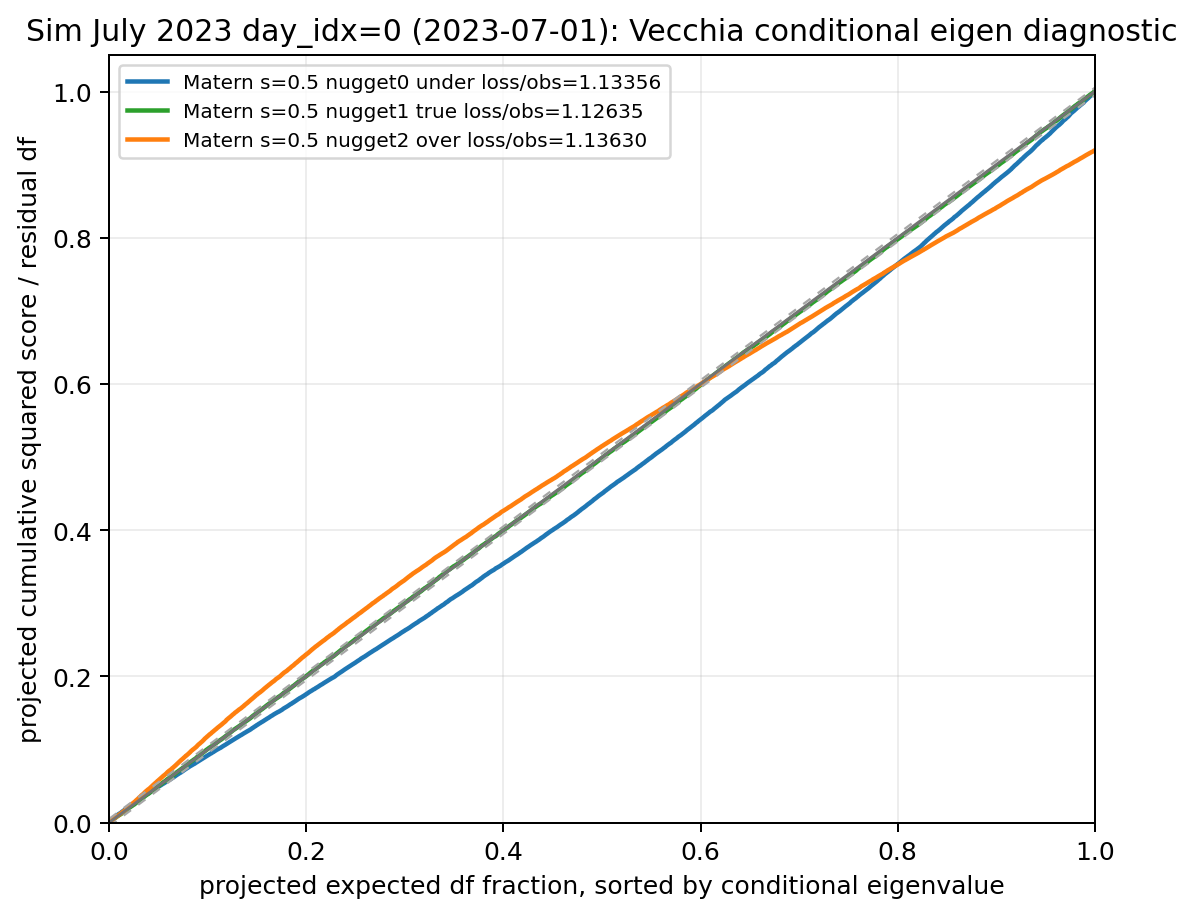

Full eigen maxmin plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/nugget_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


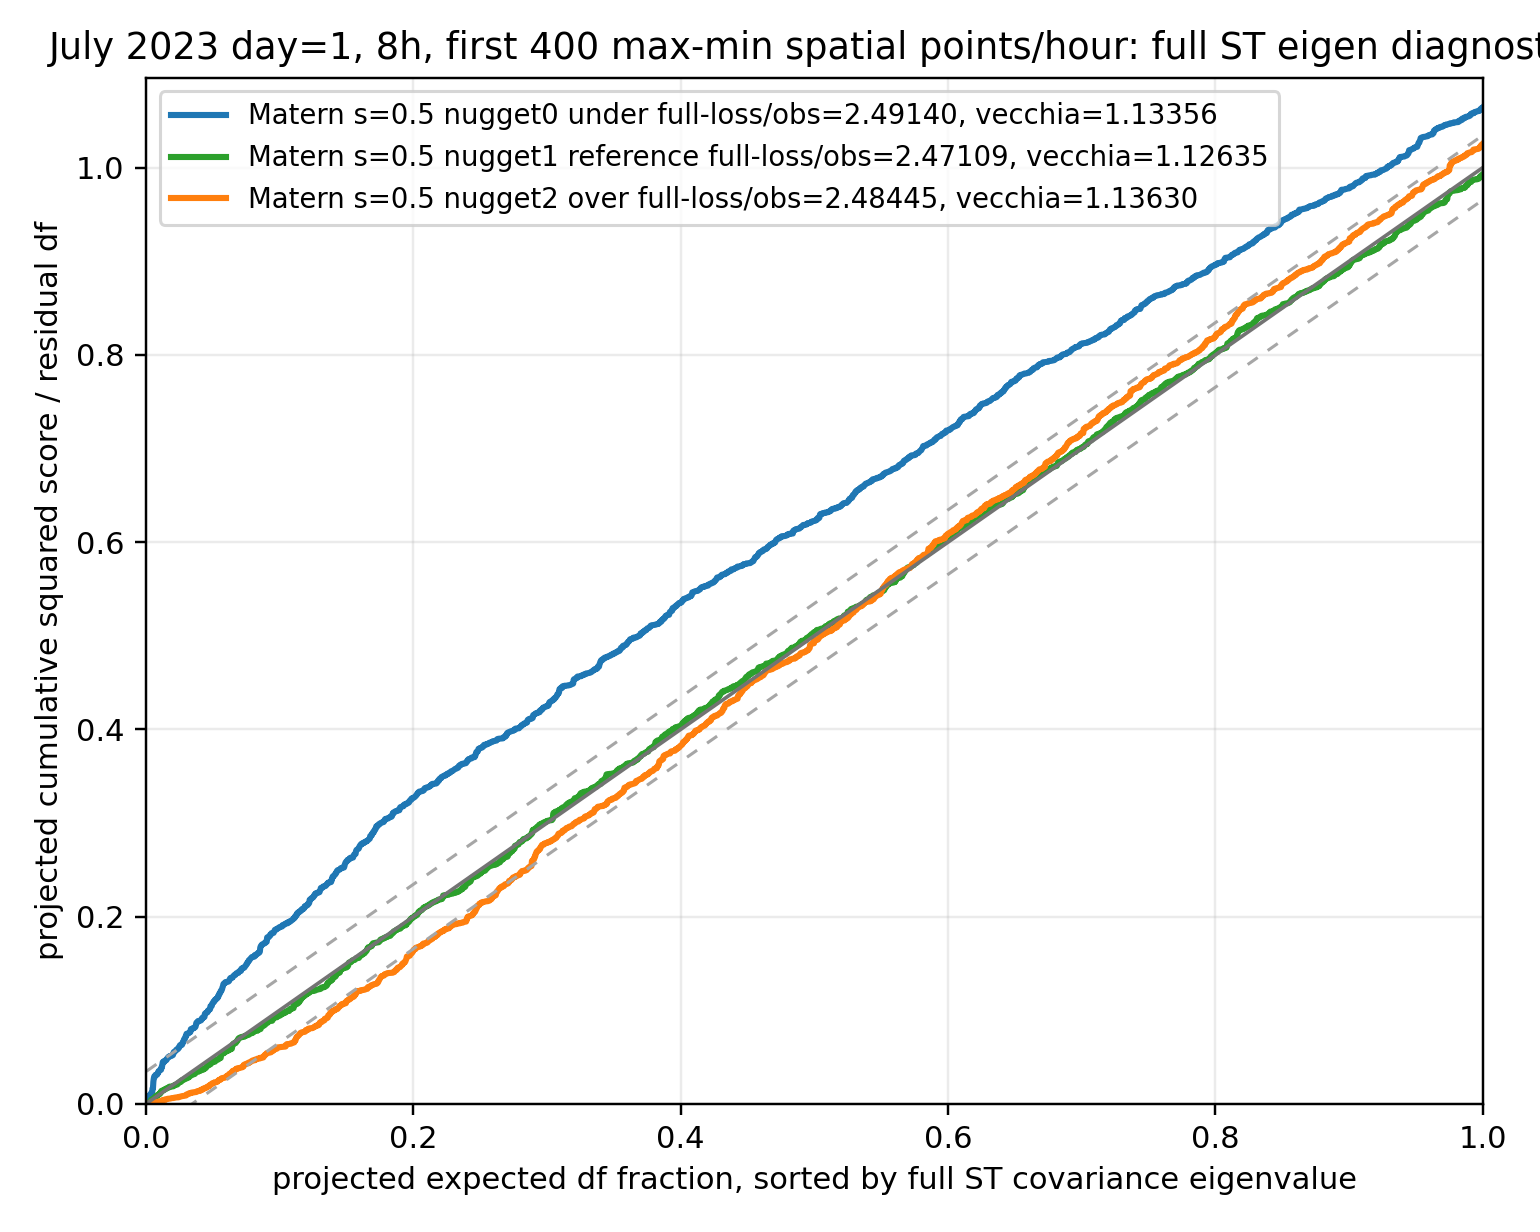


range_lon_mismatch_dgp1
Vecchia eigen plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/range_lon_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


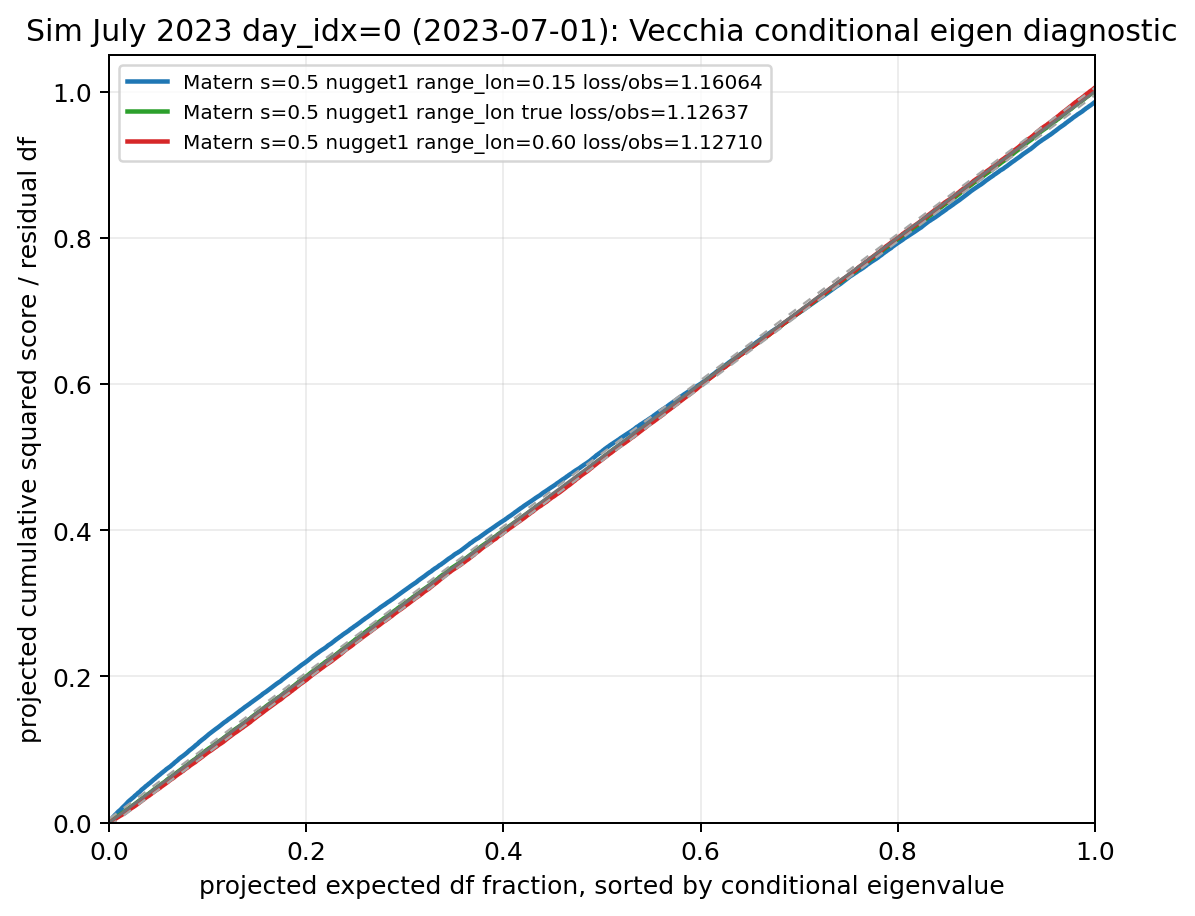

Full eigen maxmin plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/range_lon_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


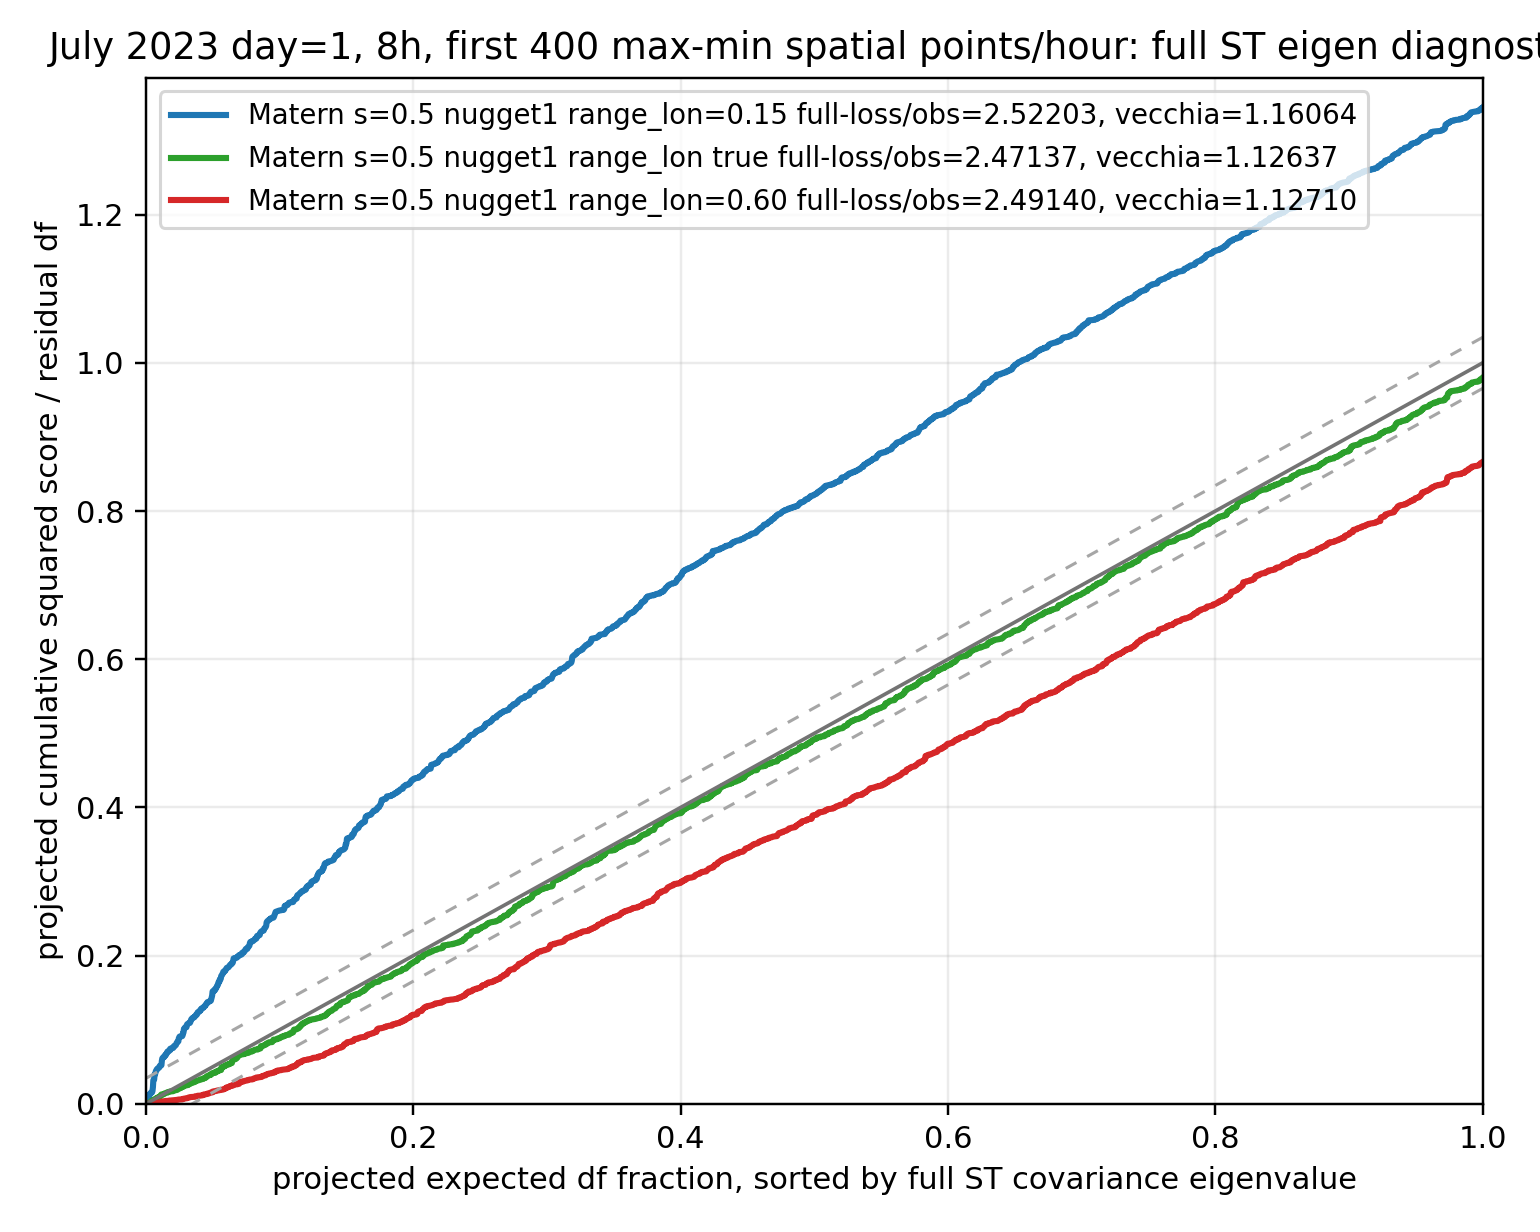


range_time_mismatch_dgp1
Vecchia eigen plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/range_time_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


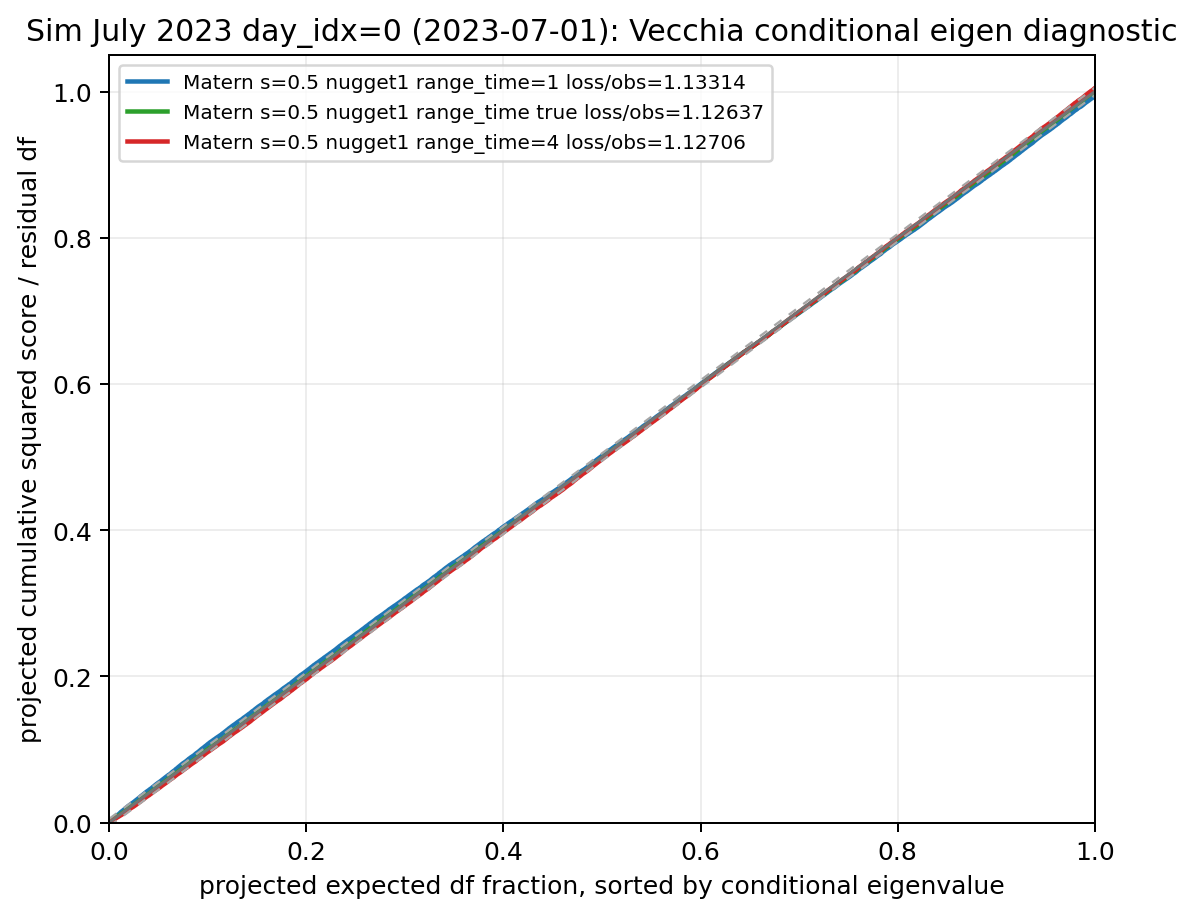

Full eigen maxmin plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/range_time_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


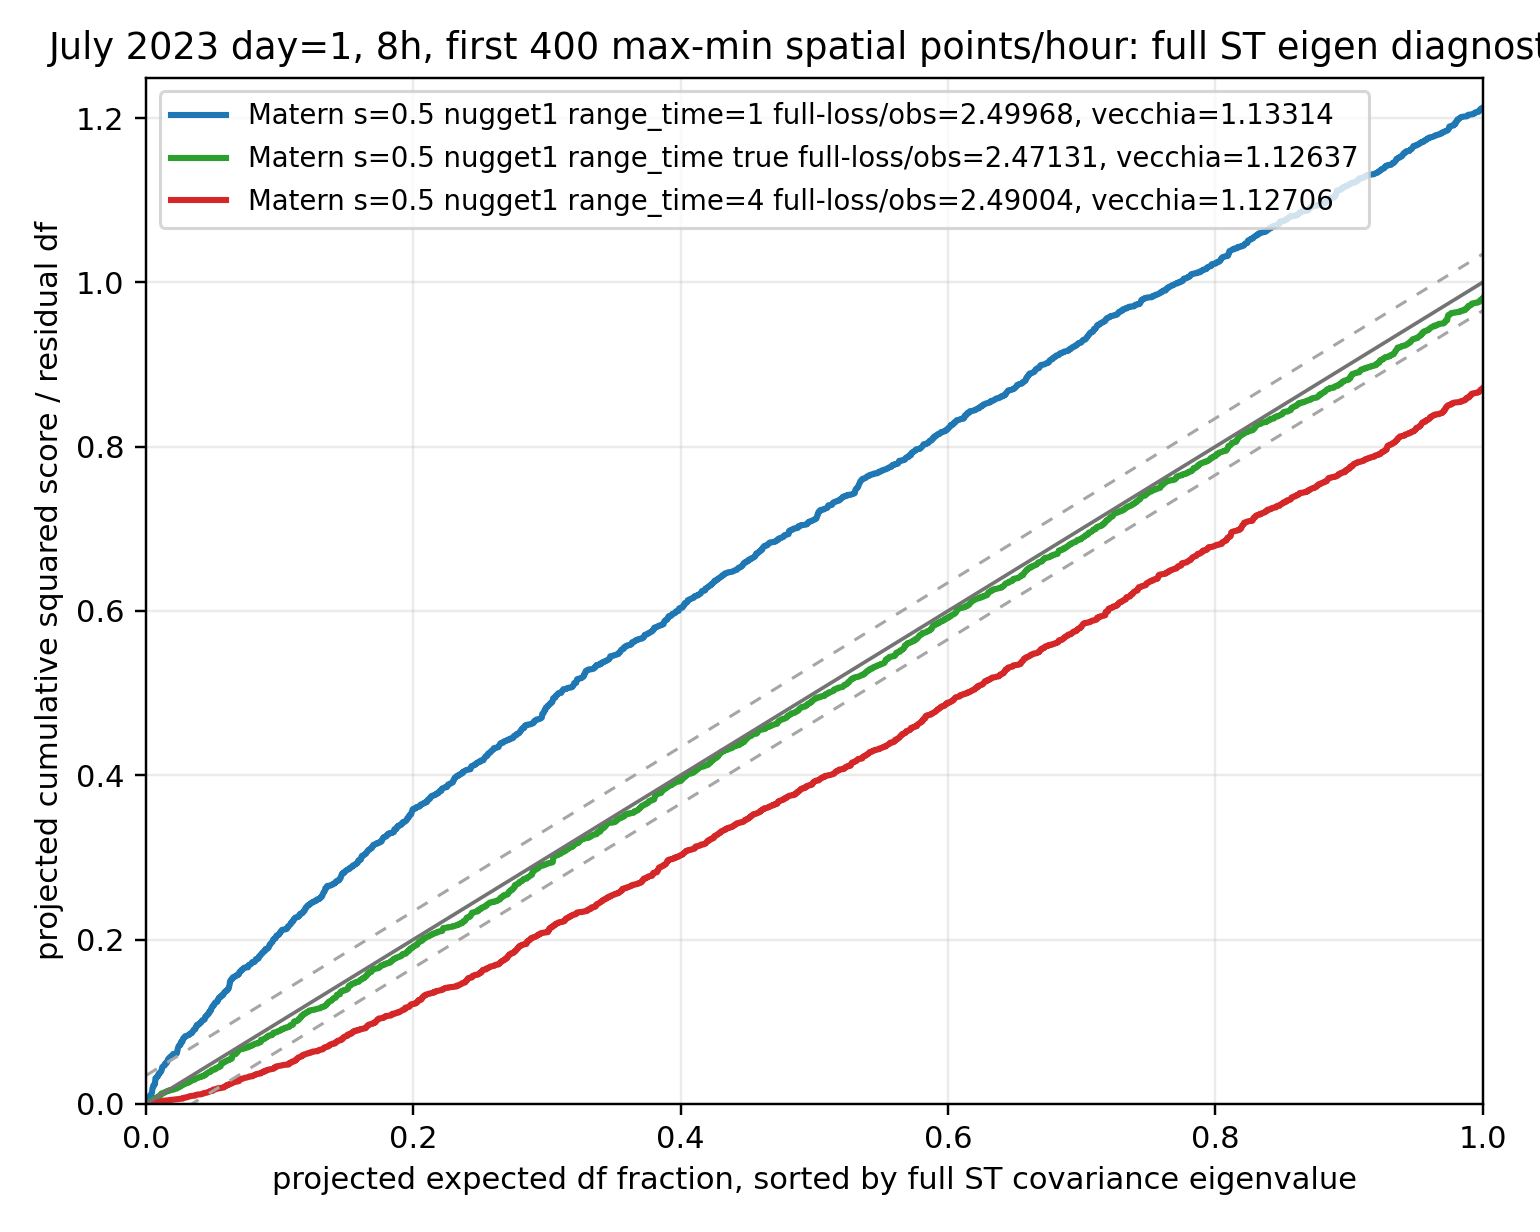


advection_mismatch_dgp1
Vecchia eigen plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_vecchia_conditional_eigen_sort_parameter_mismatch_071126/advection_mismatch_dgp1/daily_plots/year_2023/sim_2023_day01_vecchia_conditional_eigen_sort_comparison.png


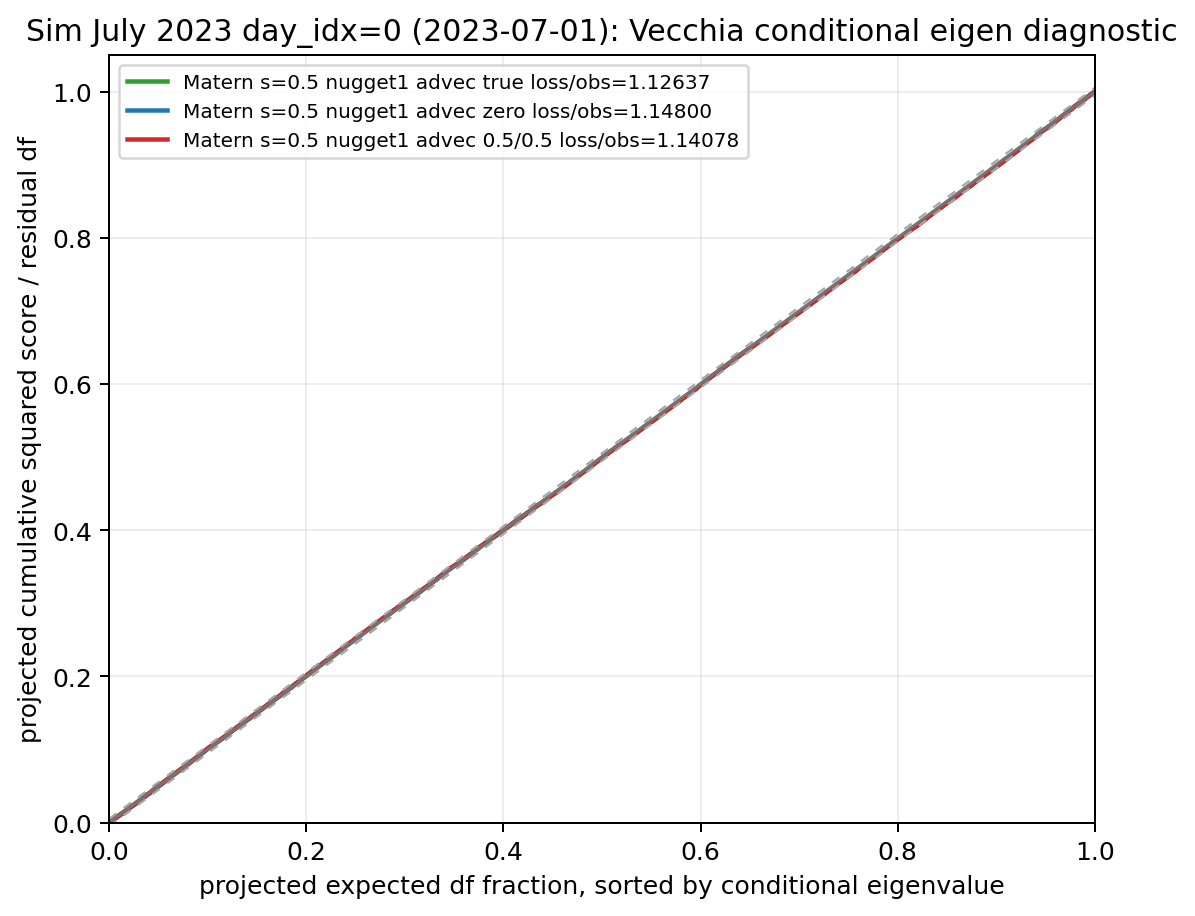

Full eigen maxmin plot: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/local_sim_s05_n1_parameter_mismatch_full_eigen_maxmin400_071126/advection_mismatch_dgp1/year2023_day01_maxmin400_per_hour/st_full_eigen_model_comparison.png


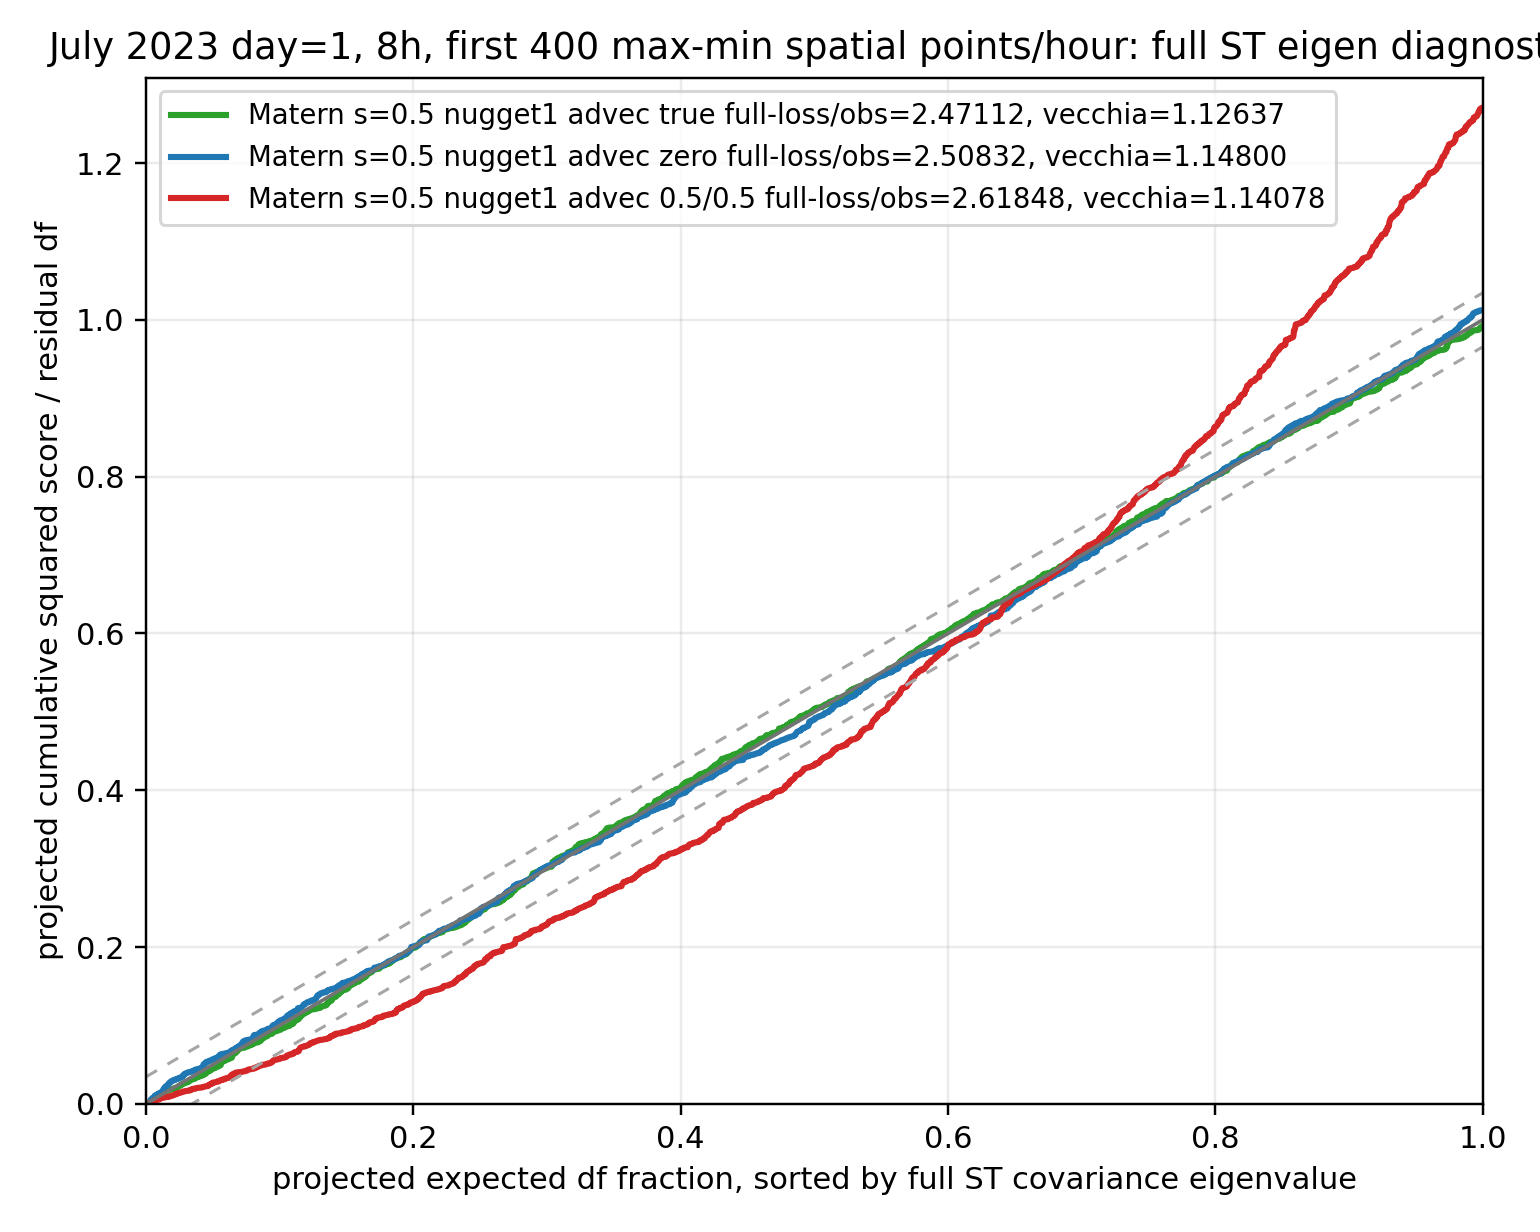

In [9]:
for experiment in EXPERIMENTS:
    vplot = vecchia_plot_png(experiment)
    fplot = full_eig_plot_png(experiment)
    print('\n' + '=' * 100)
    print(experiment)
    print('Vecchia eigen plot:', vplot)
    if vplot.exists():
        display(Image(filename=str(vplot)))
    else:
        print('Missing Vecchia eigen plot')
    print('Full eigen maxmin plot:', fplot)
    if fplot.exists():
        display(Image(filename=str(fplot)))
    else:
        print('Missing full eigen maxmin plot')